<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L4_Self_Attention_and_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=NVkqsV8J4mc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P04.pdf)

In [1]:
# Week 8, Lecture 4: Self-Attention and Transformers
from IPython.display import HTML, display

VIDEO_ID = "NVkqsV8J4mc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 4: Self-Attention and Transformers

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.4 Self-Attention and Transformers**.

This notebook builds the transformer of *Vaswani et al., NeurIPS 2017* piece by piece from plain tensors: scaled dot-product attention, multi-head attention, sinusoidal positional encoding, the encoder and decoder blocks with their residual connections and causal mask. Each piece is checked against the matching PyTorch module, then the assembled encoder-decoder is trained on a small sequence task and compared with the recurrent seq2seq model of the previous lectures.

**What you will learn**

- Why **sequential computation** is the bottleneck: the path between two positions is $T-1$ steps in an RNN and 1 step in self-attention, and what that costs in wall time on this machine.
- **Query, key, value**: $Q = XW^Q$, $K = XW^K$, $V = XW^V$, with $x \in \mathbb{R}^{512}$ and $q, k, v \in \mathbb{R}^{64}$ in the paper.
- **Scaled dot-product attention** $Z = \mathrm{softmax}\!\left(QK^{\top}/\sqrt{d_k}\right)V$, and the reason for the $\sqrt{d_k}$ that the slides assert but do not give.
- **Multi-head attention**: $h = 8$ heads of width $d_k = d_{model}/h$, concatenated and projected by $W^O$, and why that choice keeps the cost constant.
- **Positional encoding** $PE_{pos,2i} = \sin(pos / 10000^{2i/d})$, $PE_{pos,2i+1} = \cos(pos / 10000^{2i/d})$: why it is needed, why it is added rather than concatenated, and the offset property that makes it useful.
- The **encoder** and **decoder** blocks, $\mathrm{LayerNorm}(x + \mathrm{SubLayer}(x))$, the **causal mask** and **teacher forcing**.
- A transformer trained from scratch on reversing sequences, its accuracy versus sequence length against a GRU seq2seq, and what its heads look at after training.

**Contents**

1. Why drop the RNN
2. Query, key, value
3. Scaled dot-product attention
4. Multi-head attention
5. Positional encoding
6. The encoder and decoder blocks
7. Training a transformer: the reverse task
8. Attention after training
9. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

Lecture 1 of this week introduced attention as the way past the encoder-decoder bottleneck: instead of squeezing the whole input into one vector, the decoder looks back at every encoder state with a learned weighting, and scaled dot-product attention was one of the score functions listed. Lectures 2 and 3 put attention on top of recurrent decoders for captioning, visual question answering and dialog, and the third lecture ended by asking how else Visual Dialog systems could be evaluated (the slides point to consensus metrics from NLP, *Massiceti et al., arXiv 2020*). In all of those models the recurrence stayed: attention decided *where* to look, but a hidden state still had to be carried one step at a time. This lecture asks the question the slides pose directly: if attention already gives access to any state, is the recurrent network needed at all?

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, SelectionSlider, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, SelectionSlider, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100

def count_params(module):
    '''Total number of parameters in a module.'''
    return sum(p.numel() for p in module.parameters())

def to_np(x):
    '''Tensor on any device -> numpy array, for matplotlib.'''
    return x.detach().cpu().numpy()

print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. Why drop the RNN

The slides open with two problems that share one cause.

> "Sequential computation prevents parallelization."

Step $t$ of a recurrent network cannot start until step $t-1$ has produced $h_{t-1}$, so a sequence of length $T$ costs $T$ dependent steps no matter how many processors are available. And even with the gates of LSTMs and GRUs,

> "path length for co-dependent computation between states grows with sequence length."

Information from position 0 has to pass through $T-1$ intermediate states to influence position $T-1$, and every one of those states is a chance to forget. Attention was introduced to shorten that path, and the slides draw the conclusion as a question:

> "But if attention gives us access to any state, maybe we don't need the RNN?!"

The first cell counts both quantities. The second measures the cost of the sequential dependency on this machine.

In [3]:
# Path length between two positions: linear for an RNN, constant for self-attention.
print(f'  {"sequence length":>16s} {"RNN path":>10s} {"self-attention path":>21s}')
for T in (10, 50, 100, 500):
    print(f'  {T:16d} {T - 1:10d} {1:21d}')

print('\n  in an RNN, information from position 0 must pass through T-1 intermediate states')
print('  to reach position T-1; self-attention connects any two positions in a single step')

# And the sequential dependency: an RNN cannot compute step t before step t-1.
T_demo, d_demo = 8, 16
X = torch.randn(T_demo, d_demo)
Wq = torch.randn(d_demo, d_demo)
all_at_once = X @ Wq                          # every position, one matrix multiply
one_at_a_time = torch.stack([X[t] @ Wq for t in range(T_demo)])
assert torch.allclose(all_at_once, one_at_a_time, atol=1e-5)
print(f'\n  self-attention projections are one matmul over all {T_demo} positions at once;')
print('  there is no ordering constraint to respect')

   sequence length   RNN path   self-attention path
                10          9                     1
                50         49                     1
               100         99                     1
               500        499                     1

  in an RNN, information from position 0 must pass through T-1 intermediate states
  to reach position T-1; self-attention connects any two positions in a single step

  self-attention projections are one matmul over all 8 positions at once;
  there is no ordering constraint to respect


### 1.a Measuring the sequential bottleneck

The argument is about dependencies, so it should show up as wall time. Below, an `nn.LSTM` and an `nn.MultiheadAttention` layer of the same width $d = 64$ process the same batch of 32 sequences, for lengths $T$ from 8 to 256. The LSTM has to run $T$ dependent steps; the attention layer runs a handful of matrix products whose size grows with $T$ but whose *count* does not. Both directions are timed: the forward pass alone, and forward plus backward, which is what training pays. The ratio depends on the hardware: on this CPU a few cores are available, on a GPU thousands, and the gap widens accordingly.

In [4]:
# LSTM versus self-attention: wall time as a function of sequence length, on this machine.
def time_fn(fn, repeats=5):
    '''Median wall time of fn() over `repeats` runs, after one warm-up call.'''
    def sync():
        if device.type == 'cuda':
            torch.cuda.synchronize()
    fn(); sync()
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(); sync(); ts.append(time.perf_counter() - t0)
    return float(np.median(ts))

set_seed(0)
d_t, B_t = 64, 32
Ts = [8, 16, 32, 64, 128, 256]
lstm_t = nn.LSTM(d_t, d_t, batch_first=True).to(device)
attn_t = nn.MultiheadAttention(d_t, num_heads=4, batch_first=True).to(device)

timing = []                                   # rows of (T, lstm fwd, attn fwd, lstm fwd+bwd, attn fwd+bwd), in ms
for T in Ts:
    x = torch.randn(B_t, T, d_t, device=device)
    with torch.no_grad():
        f_l = time_fn(lambda: lstm_t(x))
        f_a = time_fn(lambda: attn_t(x, x, x, need_weights=False))
    b_l = time_fn(lambda: lstm_t(x)[0].sum().backward())
    b_a = time_fn(lambda: attn_t(x, x, x, need_weights=False)[0].sum().backward())
    timing.append((T, 1e3 * f_l, 1e3 * f_a, 1e3 * b_l, 1e3 * b_a))
timing = np.array(timing)

print(f'  device: {device}   batch {B_t}, width {d_t}, 4 heads')
print(f'  {"T":>5s} {"dependent steps":>16s} | {"LSTM fwd":>9s} {"attn fwd":>9s} {"ratio":>6s} | {"LSTM f+b":>9s} {"attn f+b":>9s} {"ratio":>6s}')
for T, fl, fa, bl, ba in timing:
    print(f'  {int(T):5d} {int(T):>7d} vs 1     | {fl:7.2f}ms {fa:7.2f}ms {fl / fa:6.1f} | {bl:7.2f}ms {ba:7.2f}ms {bl / ba:6.1f}')
print(f'\n  the LSTM time grows linearly with T because its T steps cannot overlap;')
print(f'  attention is {timing[:, 1].sum() / timing[:, 2].sum():.1f}x faster summed over these lengths on this device')

  device: cpu   batch 32, width 64, 4 heads
      T  dependent steps |  LSTM fwd  attn fwd  ratio |  LSTM f+b  attn f+b  ratio
      8       8 vs 1     |    0.28ms    0.10ms    2.8 |    0.70ms    0.33ms    2.1
     16      16 vs 1     |    0.51ms    0.15ms    3.3 |    1.22ms    0.54ms    2.3
     32      32 vs 1     |    0.99ms    0.24ms    4.1 |    2.32ms    0.88ms    2.6
     64      64 vs 1     |    1.92ms    0.47ms    4.1 |    4.50ms    1.43ms    3.2
    128     128 vs 1     |    3.78ms    1.14ms    3.3 |    8.93ms    3.18ms    2.8
    256     256 vs 1     |    7.67ms    3.60ms    2.1 |   17.98ms    8.81ms    2.0

  the LSTM time grows linearly with T because its T steps cannot overlap;
  attention is 2.7x faster summed over these lengths on this device


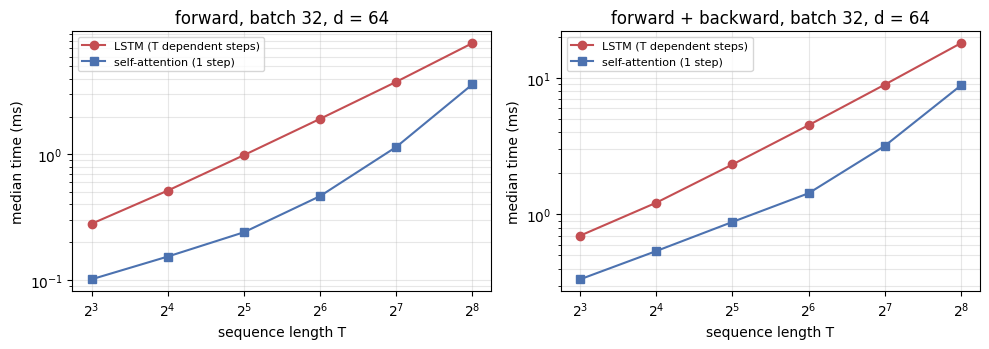

In [5]:
# Static view: time versus sequence length, both directions.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a_, (i, j, title) in zip(ax, [(1, 2, 'forward'), (3, 4, 'forward + backward')]):
    a_.plot(timing[:, 0], timing[:, i], 'o-', color='#C44E52', label='LSTM (T dependent steps)')
    a_.plot(timing[:, 0], timing[:, j], 's-', color='#4C72B0', label='self-attention (1 step)')
    a_.set_xscale('log', base=2); a_.set_yscale('log')
    a_.set_xlabel('sequence length T'); a_.set_ylabel('median time (ms)')
    a_.set_title(f'{title}, batch {B_t}, d = {d_t}'); a_.grid(alpha=0.3, which='both'); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Widget 1: sequence length versus time

Drag `T` across the lengths measured above. The two bars are the measured forward times (left) and forward-plus-backward times (right); the title reports how many dependent steps each layer needs. Watch the LSTM bar grow in step with `T` while the attention bar grows much more slowly until the $T^2$ score matrix starts to matter at the largest lengths.

In [6]:
def timing_demo(T=64):
    r = timing[Ts.index(T)]
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.2))
    for a_, (i, j, title) in zip(ax, [(1, 2, 'forward'), (3, 4, 'forward + backward')]):
        bars = a_.bar(['LSTM', 'self-attention'], [r[i], r[j]], color=['#C44E52', '#4C72B0'])
        for b, v in zip(bars, [r[i], r[j]]):
            a_.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f} ms', ha='center', va='bottom', fontsize=8)
        a_.set_ylabel('ms'); a_.margins(y=0.25)
        a_.set_title(f'{title}: LSTM / attention = {r[i] / r[j]:.1f}x', fontsize=9)
    fig.suptitle(f'T = {T}: the LSTM needs {T} dependent steps, self-attention needs 1', y=1.02)
    plt.tight_layout(); plt.show()

interact(timing_demo, T=SelectionSlider(options=Ts, value=64, description='T'));

interactive(children=(SelectionSlider(description='T', index=3, options=(8, 16, 32, 64, 128, 256), value=64), …

## 2. Query, key, value

The slides motivate self-attention with two sentences that differ in one word:

> "The animal didn't cross the street because it was too **tired**."
> "The animal didn't cross the street because it was too **wide**."

"it" refers to the animal in the first sentence and to the street in the second. A model that encodes "it" from its neighbours alone cannot tell the difference; one that can look at every other position while encoding "it" can. That is what self-attention does.

**Step 1** creates three vectors from each input vector $x_i$: a **query** $q_i$, a **key** $k_i$ and a **value** $v_i$, by multiplying with matrices learned during training:

$$Q = XW^Q, \qquad K = XW^K, \qquad V = XW^V$$

The slides give the paper's sizes, $x \in \mathbb{R}^{512}$ and $q, k, v \in \mathbb{R}^{64}$, and ask two questions. What are the dimensions of $W^Q, W^K, W^V$? And do $q, k, v$ have to be smaller than $x$? The answer to the second is no: the paper's choice of 64 is what makes multi-head attention (section 4) cost the same as a single full-width head. The first is answered by the shapes below.

In [7]:
# The projection shapes the slides ask about, and the identity they never write.
d_model, d_k, h = 512, 64, 8
n_tokens = 4

X = torch.randn(n_tokens, d_model)
WQ = torch.randn(d_model, d_k)
WK = torch.randn(d_model, d_k)
WV = torch.randn(d_model, d_k)

Q, K, V = X @ WQ, X @ WK, X @ WV

assert WQ.shape == (d_model, d_k) == (512, 64), 'the projection is d_model x d_k'
assert Q.shape == K.shape == V.shape == (n_tokens, d_k)
assert d_k == d_model // h, 'd_k should be d_model / h'

print(f'  x is {d_model}-d and q, k, v are {d_k}-d, so W^Q, W^K, W^V are {tuple(WQ.shape)}')
print(f'  the deck never states it, but d_k = d_model / h = {d_model} / {h} = {d_model // h}')
print(f'\n  X {tuple(X.shape)} -> Q, K, V each {tuple(Q.shape)}')

  x is 512-d and q, k, v are 64-d, so W^Q, W^K, W^V are (512, 64)
  the deck never states it, but d_k = d_model / h = 512 / 8 = 64

  X (4, 512) -> Q, K, V each (4, 64)


### 2.a A toy embedding for the slide's sentence

To watch the mechanism on real words we need word vectors. There is no pretrained embedding in this notebook, so each word gets a small hand-made feature vector with eight named slots: `noun`, `animate`, `inanimate`, `pronoun`, `adjective`, `says-animate` (an adjective that describes living things), `says-inanimate`, and `other` for everything else. "animal" is a noun that is animate, "street" a noun that is inanimate, "tired" an adjective that says animate, "wide" an adjective that says inanimate, and "it" is a pronoun that, on its own, carries no animacy at all.

With these features the query, key and value matrices can also be written by hand, which is the point of the exercise: **the weights below are designed, not learned**, so that every number in the attention matrix can be traced to a feature. Section 8 shows heads that were actually trained. Two attention layers are needed, exactly as in the slide's story:

- **Layer 1, "the pronoun reads the adjective".** The query of a pronoun looks for adjective keys. The value of an adjective carries its `says-animate` or `says-inanimate` feature into the pronoun's `animate` or `inanimate` slot. After the residual connection, "it" knows whether it is animate.
- **Layer 2, "the pronoun finds the matching noun".** The query of a pronoun now carries its animacy and looks for noun keys with the same animacy. "it" attends to "animal" in the tired sentence and to "street" in the wide sentence.

In [8]:
# Word features, and hand-designed projections for the two-layer "it -> animal / street" mechanism.
FEATS = ['noun', 'animate', 'inanimate', 'pronoun', 'adjective', 'says-animate', 'says-inanimate', 'other']
LEXICON = {'animal': ['noun', 'animate'], 'street': ['noun', 'inanimate'], 'it': ['pronoun'],
           'tired': ['adjective', 'says-animate'], 'wide': ['adjective', 'says-inanimate']}
SENT_TIRED = "The animal didn't cross the street because it was too tired".split()
SENT_WIDE = "The animal didn't cross the street because it was too wide".split()

def embed(words):
    '''Toy embedding: a 0/1 feature vector per word from the tiny lexicon above.'''
    X = torch.zeros(len(words), len(FEATS))
    for i, w in enumerate(words):
        for f in LEXICON.get(w.lower(), ['other']):
            X[i, FEATS.index(f)] = 1.0
    return X

def slot(name):
    return FEATS.index(name)

d_toy, gain = len(FEATS), 8.0                    # gain sets how sharp the hand-made heads are
# Layer 1: pronoun queries match adjective keys; adjective values carry animacy into the pronoun.
W1Q = torch.zeros(d_toy, 2); W1Q[slot('pronoun'), 0] = gain
W1K = torch.zeros(d_toy, 2); W1K[slot('adjective'), 0] = 1.0
W1V = torch.zeros(d_toy, d_toy)
W1V[slot('says-animate'), slot('animate')] = 1.0
W1V[slot('says-inanimate'), slot('inanimate')] = 1.0
# Layer 2: pronoun queries carry their animacy and look for a noun with the same animacy.
W2Q = torch.zeros(d_toy, 3); W2Q[slot('animate'), 0] = gain; W2Q[slot('inanimate'), 1] = gain; W2Q[slot('pronoun'), 2] = gain
W2K = torch.zeros(d_toy, 3); W2K[slot('animate'), 0] = 1.0; W2K[slot('inanimate'), 1] = 1.0; W2K[slot('noun'), 2] = 1.0
W2V = torch.eye(d_toy)

X_tired, X_wide = embed(SENT_TIRED), embed(SENT_WIDE)
q1, k1, v1 = X_tired @ W1Q, X_tired @ W1K, X_tired @ W1V
print(f'  {len(SENT_TIRED)} words, each a {d_toy}-d feature vector: X {tuple(X_tired.shape)}')
print(f'  layer-1 projections: W^Q {tuple(W1Q.shape)}, W^K {tuple(W1K.shape)}, W^V {tuple(W1V.shape)}')
print(f'  q, k are {q1.shape[1]}-d, v is {v1.shape[1]}-d: q and k only need to agree with each other')
for w in ['animal', 'street', 'it', 'tired', 'wide']:
    X_w = embed([w])[0]
    print(f'  {w:>7s}: features {[f for f in FEATS if X_w[slot(f)] > 0]}')

  11 words, each a 8-d feature vector: X (11, 8)
  layer-1 projections: W^Q (8, 2), W^K (8, 2), W^V (8, 8)
  q, k are 2-d, v is 8-d: q and k only need to agree with each other
   animal: features ['noun', 'animate']
   street: features ['noun', 'inanimate']
       it: features ['pronoun']
    tired: features ['adjective', 'says-animate']
     wide: features ['adjective', 'says-inanimate']


## 3. Scaled dot-product attention

**Step 2** scores every word of the sentence against the word being encoded, by the dot product of its query with each key. For "Thinking" in the slides' two-word example, the first score is $q_1 \cdot k_1$ (with itself) and the second $q_1 \cdot k_2$ (with "Machines"). The scores are then divided by $\sqrt{d_k}$; the slides call the result *scaled dot-product attention* and say only that the division "leads to more stable gradients". **Step 3** is a softmax, giving normalized weights that say how much each word is expressed at this position. **Step 4** multiplies each value vector by its weight, keeping the words to focus on intact and drowning out the irrelevant ones, and **step 5** sums the weighted values. In matrix form:

$$Z = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

With $d_k = 64$ the divisor is $\sqrt{64} = 8$, the "divide by 8" in the slides' figure. The worked example there scores 112 and 96, giving 14 and 12 after scaling, and a softmax of 0.88 and 0.12. The first cell reproduces those numbers exactly.

In [9]:
# Reproduce the slides' worked numbers exactly.
raw_scores = torch.tensor([112.0, 96.0])
scaled = raw_scores / math.sqrt(d_k)
alpha = torch.softmax(scaled, dim=0)

assert math.sqrt(d_k) == 8.0
assert torch.allclose(scaled, torch.tensor([14.0, 12.0]))
assert torch.allclose(alpha, torch.tensor([0.8808, 0.1192]), atol=1e-4)

print(f'  raw scores      {raw_scores.tolist()}')
print(f'  / sqrt(d_k) = 8 {scaled.tolist()}')
print(f'  softmax         {[round(v, 4) for v in alpha.tolist()]}  (the slides print 0.88 and 0.12)')
print(f'  sums to {alpha.sum():.6f}')

  raw scores      [112.0, 96.0]
  / sqrt(d_k) = 8 [14.0, 12.0]
  softmax         [0.8808, 0.1192]  (the slides print 0.88 and 0.12)
  sums to 1.000000


### 3.a Why divide by $\sqrt{d_k}$

If the entries of $q$ and $k$ are independent with zero mean and unit variance, their dot product $\sum_{j=1}^{d_k} q_j k_j$ has variance $d_k$, so its standard deviation grows like $\sqrt{d_k}$. Logits that are spread over tens of units push the softmax to a one-hot vector, and the gradient of a saturated softmax is essentially zero. Dividing by $\sqrt{d_k}$ brings the standard deviation back to 1 whatever $d_k$ is. The cell measures all three quantities: the spread of the raw dot products, the spread after scaling, and what unscaled logits do to a softmax. For the last one, a single row of logits is too noisy to trust, so the 4000 dot products are reshaped into 500 rows of 8 unscaled scores each, the softmax is taken per row, and the cell reports the mean of the row maxima and the median over rows of the norm of the gradient of the row maximum with respect to that row's logits (the median, because the norm collapses over many orders of magnitude).

In [10]:
# Dot products of unit-variance vectors spread like sqrt(d_k); scaling holds the spread at 1.
set_seed(0)
print(f'  {"d_k":>6s} {"std of q.k":>11s} {"std after /sqrt(d_k)":>21s} {"mean max softmax":>17s} {"median grad norm":>17s}')
sat_rows = []
for dk in (8, 32, 128, 512, 2048):
    q = torch.randn(4000, dk)
    k = torch.randn(4000, dk)
    dots = (q * k).sum(1)                                  # 4000 dot products
    std_raw, std_scaled = dots.std().item(), (dots / math.sqrt(dk)).std().item()
    logits = dots.view(500, 8).clone().requires_grad_(True)   # 500 rows of 8 unscaled scores
    p = torch.softmax(logits, dim=1)
    p.max(1).values.sum().backward()                       # rows are independent: grad of each row's maximum
    row_max, grad_norm = p.max(1).values.mean().item(), logits.grad.norm(dim=1).median().item()
    sat_rows.append((dk, row_max, grad_norm))
    assert abs(std_raw / math.sqrt(dk) - 1) < 0.1, 'std should grow like sqrt(d_k)'
    assert abs(std_scaled - 1) < 0.1, 'scaling should restore unit spread'
    print(f'  {dk:6d} {std_raw:11.2f} {std_scaled:21.2f} {row_max:17.3f} {grad_norm:17.1e}')

assert sat_rows[-1][2] < 1e-4, 'at d_k = 2048 the unscaled softmax gradient should have collapsed'
orders = math.log10(sat_rows[0][2] / sat_rows[-1][2])
print(f'\n  the raw spread is sqrt(d_k) to within 10% every time; from d_k = {sat_rows[0][0]} to {sat_rows[-1][0]} the unscaled')
print(f'  softmax rows go one-hot (mean maximum {sat_rows[0][1]:.2f} -> {sat_rows[-1][1]:.2f}) and the median gradient norm')
print(f'  falls by {orders:.0f} orders of magnitude ({sat_rows[0][2]:.1e} -> {sat_rows[-1][2]:.0e}); the scaled spread stays at 1 for every d_k')

     d_k  std of q.k  std after /sqrt(d_k)  mean max softmax  median grad norm
       8        2.81                  0.99             0.680           2.5e-01
      32        5.71                  1.01             0.840           1.0e-01
     128       11.26                  1.00             0.916           9.4e-03
     512       22.97                  1.02             0.959           2.8e-05
    2048       45.38                  1.00             0.981           1.2e-10

  the raw spread is sqrt(d_k) to within 10% every time; from d_k = 8 to 2048 the unscaled
  softmax rows go one-hot (mean maximum 0.68 -> 0.98) and the median gradient norm
  falls by 9 orders of magnitude (2.5e-01 -> 1e-10); the scaled spread stays at 1 for every d_k


### 3.b The function, checked against PyTorch

`attention` below is the whole of steps 2 to 5 in four lines, written for tensors of shape `(..., T, d_k)` so the same function serves one head or a batch of heads. An optional boolean mask marks the positions that must not be attended (used by the decoder in section 6). PyTorch ships the same computation as `F.scaled_dot_product_attention`; the two must agree, with and without the causal mask.

In [11]:
# Full scaled dot-product attention, and its check against F.scaled_dot_product_attention.
def attention(Q, K, V, mask=None):
    '''softmax(Q K^T / sqrt(d_k)) V for tensors (..., T, d_k). mask: bool, True = blocked.
    Returns the output Z (..., T_q, d_v) and the attention matrix A (..., T_q, T_k).'''
    scores = Q @ K.transpose(-2, -1) / math.sqrt(Q.shape[-1])
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    A = torch.softmax(scores, dim=-1)
    return A @ V, A

Z, A = attention(Q, K, V)
assert A.shape == (n_tokens, n_tokens), 'the attention matrix is tokens x tokens'
assert torch.allclose(A.sum(-1), torch.ones(n_tokens), atol=1e-5), 'every row must sum to 1'
assert Z.shape == (n_tokens, d_k)
print(f'  Q {tuple(Q.shape)} @ K^T {tuple(K.T.shape)} -> scores {tuple(A.shape)}')
print(f'  softmax rows sum to 1: {A.sum(-1).tolist()}')
print(f'  output Z {tuple(Z.shape)}, same width as V')

# Batched check against PyTorch, plain and causal.
set_seed(1)
Qb, Kb, Vb = (torch.randn(2, 3, 5, 8) for _ in range(3))     # (batch, heads, T, d_k)
ref = F.scaled_dot_product_attention(Qb, Kb, Vb)
ours, _ = attention(Qb, Kb, Vb)
assert torch.allclose(ours, ref, atol=1e-6), 'disagrees with F.scaled_dot_product_attention'
causal5 = torch.triu(torch.ones(5, 5, dtype=torch.bool), diagonal=1)
ref_c = F.scaled_dot_product_attention(Qb, Kb, Vb, is_causal=True)
ours_c, _ = attention(Qb, Kb, Vb, mask=causal5)
assert torch.allclose(ours_c, ref_c, atol=1e-6), 'causal version disagrees'
print(f'\n  vs F.scaled_dot_product_attention: max |diff| {(ours - ref).abs().max():.1e} (plain), '
      f'{(ours_c - ref_c).abs().max():.1e} (causal)')

  Q (4, 64) @ K^T (64, 4) -> scores (4, 4)
  softmax rows sum to 1: [1.0, 1.0, 1.0, 1.0]
  output Z (4, 64), same width as V

  vs F.scaled_dot_product_attention: max |diff| 2.4e-07 (plain), 2.4e-07 (causal)


### 3.c The five steps on the word "it"

Now the sentence. The cell runs the two hand-designed layers from section 2 on both sentences and prints the five steps for the query "it" in layer 2: the scaled scores against every word, the softmax weights, and the animacy slots of the weighted sum. Each layer adds its output back to its input (the residual connection of section 6), which is how the animacy that "it" collects from the adjective in layer 1 becomes part of its query in layer 2.

In [12]:
# Two hand-designed attention layers on the slide's two sentences.
def two_layer_pronoun_attention(X):
    '''Layer 1: pronoun reads the adjective. Layer 2: pronoun finds the noun of matching animacy.
    Returns the residual outputs and the two attention matrices.'''
    Z1, A1 = attention(X @ W1Q, X @ W1K, X @ W1V)
    X1 = X + Z1                                              # residual: "it" now carries animacy
    Z2, A2 = attention(X1 @ W2Q, X1 @ W2K, X1 @ W2V)
    return X1, X1 + Z2, A1, A2

it = SENT_TIRED.index('it')
results = {}
for name, words, Xs in [('tired', SENT_TIRED, X_tired), ('wide', SENT_WIDE, X_wide)]:
    X1, X2, A1, A2 = two_layer_pronoun_attention(Xs)
    scores2 = (X1 @ W2Q) @ (X1 @ W2K).T / math.sqrt(W2Q.shape[1])
    results[name] = dict(words=words, A1=A1, A2=A2, scores_it=scores2[it])
    print(f'  sentence ending in "{name}":')
    print(f'    layer 1, "it" attends to: ' + ', '.join(f'{w} {a:.2f}' for w, a in zip(words, A1[it]) if a > 0.05))
    print(f'    after the residual, "it" has animate = {X1[it, slot("animate")]:.2f}, inanimate = {X1[it, slot("inanimate")]:.2f}')
    print(f'    step 2, scaled scores of "it" vs each word: ' + ' '.join(f'{s:.1f}' for s in scores2[it]))
    print(f'    step 3, softmax:                            ' + ' '.join(f'{a:.2f}' for a in A2[it]))
    print(f'    steps 4-5, weighted sum has animate = {(A2[it] @ (X1 @ W2V))[slot("animate")]:.2f}, '
          f'inanimate = {(A2[it] @ (X1 @ W2V))[slot("inanimate")]:.2f}')

A_tired, A_wide = results['tired']['A2'], results['wide']['A2']
assert A_tired[it, SENT_TIRED.index('animal')] > 0.9, '"it" should attend to "animal" when tired'
assert A_wide[it, SENT_WIDE.index('street')] > 0.9, '"it" should attend to "street" when wide'
print(f'\n  "it" -> "animal": {A_tired[it, SENT_TIRED.index("animal")]:.3f} (tired)   '
      f'"it" -> "street": {A_wide[it, SENT_WIDE.index("street")]:.3f} (wide)')

  sentence ending in "tired":
    layer 1, "it" attends to: tired 0.97
    after the residual, "it" has animate = 0.97, inanimate = 0.00
    step 2, scaled scores of "it" vs each word: 0.4 9.5 0.4 0.4 0.4 5.0 0.4 4.3 0.4 0.4 0.4
    step 3, softmax:                            0.00 0.98 0.00 0.00 0.00 0.01 0.00 0.01 0.00 0.00 0.00
    steps 4-5, weighted sum has animate = 1.08, inanimate = 0.01
  sentence ending in "wide":
    layer 1, "it" attends to: wide 0.97
    after the residual, "it" has animate = 0.00, inanimate = 0.97
    step 2, scaled scores of "it" vs each word: 0.4 5.0 0.4 0.4 0.4 9.5 0.4 4.3 0.4 0.4 0.4
    step 3, softmax:                            0.00 0.01 0.00 0.00 0.00 0.98 0.00 0.01 0.00 0.00 0.00
    steps 4-5, weighted sum has animate = 0.01, inanimate = 1.08

  "it" -> "animal": 0.982 (tired)   "it" -> "street": 0.982 (wide)


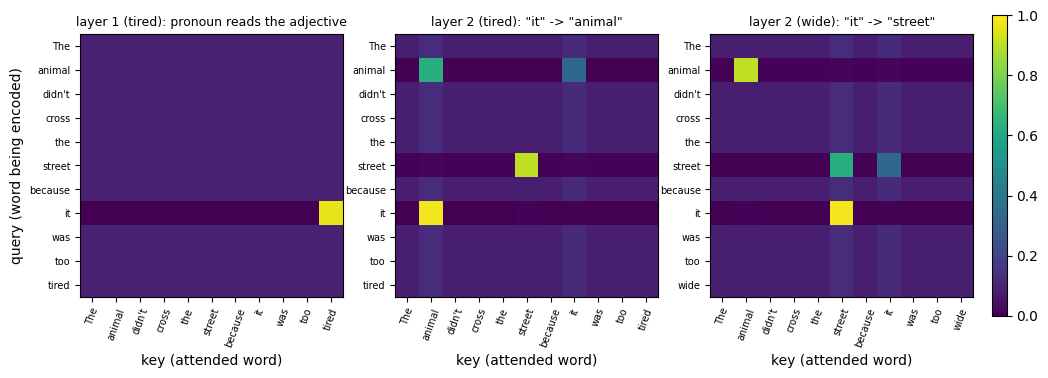

In [13]:
# The attention matrices of layer 2 for the two sentences, and the layer-1 matrix that made them possible.
fig, ax = plt.subplots(1, 3, figsize=(12, 3.9))
panels = [(results['tired']['A1'], SENT_TIRED, 'layer 1 (tired): pronoun reads the adjective'),
          (A_tired, SENT_TIRED, 'layer 2 (tired): "it" -> "animal"'),
          (A_wide, SENT_WIDE, 'layer 2 (wide): "it" -> "street"')]
for a_, (A_, words, title) in zip(ax, panels):
    im = a_.imshow(to_np(A_), cmap='viridis', vmin=0, vmax=1)
    a_.set_xticks(range(len(words))); a_.set_xticklabels(words, rotation=70, fontsize=7)
    a_.set_yticks(range(len(words))); a_.set_yticklabels(words, fontsize=7)
    a_.set_title(title, fontsize=9); a_.set_xlabel('key (attended word)')
ax[0].set_ylabel('query (word being encoded)')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.show()

### 3.d The softmax as a temperature

Dividing the scores by $\sqrt{d_k}$ is a fixed choice of **temperature**: $\mathrm{softmax}(s/\tau)$ with $\tau = \sqrt{d_k}$. A smaller $\tau$ sharpens the distribution towards the best-matching key; a larger one flattens it towards the uniform average of all values, which is what an untrained head mostly computes. The sweep below applies extra temperatures $\tau$ to the layer-2 scores of "it" (with $\tau = 1$ being the standard $\sqrt{d_k}$ scaling) and reports the entropy of the resulting row in bits: 0 bits is one-hot, $\log_2 11 = 3.46$ bits is uniform over the eleven words.

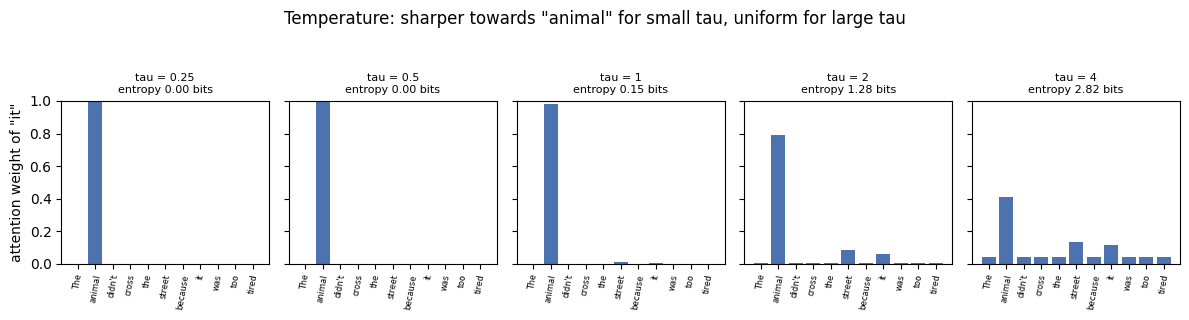

In [14]:
# Static sweep: the "it" row at several temperatures, for the sentence ending in "tired".
def entropy_bits(p):
    p = p[p > 0]
    return float(-(p * torch.log2(p)).sum())

taus = [0.25, 0.5, 1.0, 2.0, 4.0]
fig, ax = plt.subplots(1, len(taus), figsize=(12, 3.0), sharey=True)
for a_, tau in zip(ax, taus):
    row = torch.softmax(results['tired']['scores_it'] / tau, dim=0)
    a_.bar(range(len(SENT_TIRED)), to_np(row), color='#4C72B0')
    a_.set_xticks(range(len(SENT_TIRED))); a_.set_xticklabels(SENT_TIRED, rotation=80, fontsize=6)
    a_.set_title(f'tau = {tau:g}\nentropy {entropy_bits(row):.2f} bits', fontsize=8)
    a_.set_ylim(0, 1)
ax[0].set_ylabel('attention weight of "it"')
fig.suptitle('Temperature: sharper towards "animal" for small tau, uniform for large tau', y=1.05)
plt.tight_layout(); plt.show()

### Widget 2: softmax temperature

Drag `tau` from 0.25 to 8 and switch the sentence. Below about 0.5 the row is one-hot on the referent; above 4 the entropy approaches the uniform 3.46 bits and "it" is encoded as the average of every word, referent included. The standard scaling is `tau = 1`.

In [15]:
def temperature_demo(tau=1.0, sentence='tired'):
    r = results[sentence]
    row = torch.softmax(r['scores_it'] / tau, dim=0)
    fig, a_ = plt.subplots(figsize=(7, 3.2))
    a_.bar(range(len(r['words'])), to_np(row), color='#4C72B0')
    a_.set_xticks(range(len(r['words']))); a_.set_xticklabels(r['words'], rotation=70, fontsize=8)
    a_.set_ylim(0, 1); a_.set_ylabel('attention weight of "it"')
    top = r['words'][int(row.argmax())]
    a_.set_title(f'tau = {tau:g}: entropy {entropy_bits(row):.2f} bits (uniform = {math.log2(len(row)):.2f}), '
                 f'top word "{top}" at {row.max():.2f}', fontsize=9)
    plt.tight_layout(); plt.show()

interact(temperature_demo,
         tau=SelectionSlider(options=[0.25, 0.5, 1.0, 2.0, 4.0, 8.0], value=1.0, description='tau'),
         sentence=Dropdown(options=['tired', 'wide'], value='tired', description='sentence'));

interactive(children=(SelectionSlider(description='tau', index=2, options=(0.25, 0.5, 1.0, 2.0, 4.0, 8.0), val…

## 4. Multi-head attention

The slides give two reasons to run several attention heads in parallel.

> "Expands model's ability to focus on different positions. In example above, $z_1$ contains a bit of every other encoding, but dominated by actual word itself."

> "Gives attention layer multiple 'representation subspaces'; we have not one, but multiple sets of Query/Key/Value weight matrices."

Each head $i$ has its own $W^Q_i, W^K_i, W^V_i$ and produces its own $Z_i$. The $h = 8$ outputs are concatenated and projected once more by $W^O$:

$$Z = \mathrm{Concat}(Z_0, \dots, Z_7)\,W^O$$

Because each head is $d_k = d_{model}/h = 64$ wide, the concatenation is $8 \times 64 = 512 = d_{model}$ wide again, so multi-head attention is **shape-preserving**, which the residual connection in section 6 requires. The implementation below is batched, takes separate query and key/value inputs so that the same module serves self-attention and the decoder's attention over the encoder (section 6), and returns every head's attention matrix for inspection.

In [16]:
# Multi-head attention from scratch, batched, with separate query and key/value inputs.
class MultiHeadAttention(nn.Module):
    '''h heads of scaled dot-product attention in parallel, concatenated and projected by W^O.
    x_q: (B, T_q, d_model); x_kv: (B, T_k, d_model), defaults to x_q (self-attention).
    mask: bool, True = blocked, broadcastable to (B, h, T_q, T_k).'''
    def __init__(self, d_model=512, h=8, bias=True):
        super().__init__()
        assert d_model % h == 0, 'd_model must split evenly across heads'
        self.h, self.d_k = h, d_model // h
        self.WQ = nn.Linear(d_model, d_model, bias=bias)    # all h heads' W^Q_i side by side
        self.WK = nn.Linear(d_model, d_model, bias=bias)
        self.WV = nn.Linear(d_model, d_model, bias=bias)
        self.WO = nn.Linear(d_model, d_model, bias=bias)

    def split_heads(self, x):
        B, T, d = x.shape
        return x.view(B, T, self.h, self.d_k).transpose(1, 2)          # (B, h, T, d_k)

    def forward(self, x_q, x_kv=None, mask=None):
        x_kv = x_q if x_kv is None else x_kv
        q, k, v = self.split_heads(self.WQ(x_q)), self.split_heads(self.WK(x_kv)), self.split_heads(self.WV(x_kv))
        z, A = attention(q, k, v, mask)                                  # z: (B, h, T_q, d_k)
        B, _, T_q, _ = z.shape
        z = z.transpose(1, 2).reshape(B, T_q, self.h * self.d_k)         # concatenate the heads
        return self.WO(z), A

set_seed(0)
mha512 = MultiHeadAttention(d_model, h, bias=False).to(device)
X_seq = torch.randn(1, 10, d_model, device=device)
out, A_heads = mha512(X_seq)

assert out.shape == X_seq.shape, 'multi-head attention must be shape-preserving'
assert A_heads.shape == (1, h, 10, 10), 'one attention matrix per head'
assert torch.allclose(A_heads.sum(-1), torch.ones(1, h, 10, device=device), atol=1e-5)

n_params = count_params(mha512)
expected = 4 * d_model * d_model
assert n_params == expected == 1_048_576 == 2 ** 20

print(f'  input {tuple(X_seq.shape)} -> output {tuple(out.shape)}   (shape-preserving)')
print(f'  {h} heads, each {mha512.d_k}-d; concatenated {h} x {mha512.d_k} = {h * mha512.d_k} = d_model')
print(f'  parameters (no bias): 4 x {d_model} x {d_model} = {n_params:,} = 2^{int(math.log2(n_params))}')

  input (1, 10, 512) -> output (1, 10, 512)   (shape-preserving)
  8 heads, each 64-d; concatenated 8 x 64 = 512 = d_model
  parameters (no bias): 4 x 512 x 512 = 1,048,576 = 2^20


### 4.a The idiomatic version, and the check

PyTorch's `nn.MultiheadAttention` computes the same thing with $W^Q, W^K, W^V$ packed into one `in_proj_weight` of shape $(3d_{model}, d_{model})$ and $W^O$ as `out_proj`. Once the weights are copied across, the two must agree to floating-point precision.

In [17]:
# Our multi-head attention == nn.MultiheadAttention, once the weights are mapped across.
set_seed(0)
ours = MultiHeadAttention(d_model=64, h=4, bias=True).to(device)
ref = nn.MultiheadAttention(embed_dim=64, num_heads=4, bias=True, batch_first=True).to(device)
with torch.no_grad():
    ref.in_proj_weight.copy_(torch.cat([ours.WQ.weight, ours.WK.weight, ours.WV.weight]))
    ref.in_proj_bias.copy_(torch.cat([ours.WQ.bias, ours.WK.bias, ours.WV.bias]))
    ref.out_proj.weight.copy_(ours.WO.weight); ref.out_proj.bias.copy_(ours.WO.bias)

x_t = torch.randn(3, 7, 64, device=device)
our_out, our_A = ours(x_t)
ref_out, ref_A = ref(x_t, x_t, x_t, average_attn_weights=False)
assert torch.allclose(our_out, ref_out, atol=1e-5), 'disagrees with nn.MultiheadAttention'
assert torch.allclose(our_A, ref_A, atol=1e-5), 'attention weights disagree'
print(f'  ours vs nn.MultiheadAttention: max |difference| = {(our_out - ref_out).abs().max():.2e} (outputs), '
      f'{(our_A - ref_A).abs().max():.2e} (attention)')
print('  the from-scratch implementation is exactly what PyTorch computes')

  ours vs nn.MultiheadAttention: max |difference| = 1.19e-07 (outputs), 5.96e-08 (attention)
  the from-scratch implementation is exactly what PyTorch computes


### 4.b Why $d_k = d_{model}/h$: the cost of heads

The slide's answer to "do $q, k, v$ have to be smaller than $x$?" is "no, this was done perhaps to make computation of multi-headed attention constant". That is a measurable statement. For $h$ heads of width $d_k$, the projections hold $3 \cdot d_{model} \cdot h d_k + h d_k \cdot d_{model}$ weights and the scores $QK^{\top}$ cost $h \cdot T^2 \cdot d_k$ multiply-adds. With $d_k = d_{model}/h$ both reduce to $4 d_{model}^2$ and $T^2 d_{model}$, independent of $h$: eight heads cost exactly what one full-width head costs. If instead every head kept $d_k = d_{model}$, both would grow $h$-fold.

   heads  d_k = 512/h       params  score FLOPs |  d_k = 512       params  score FLOPs
       1          512    1,048,576    5,120,000 |        512    1,048,576    5,120,000
       2          256    1,048,576    5,120,000 |        512    2,097,152   10,240,000
       4          128    1,048,576    5,120,000 |        512    4,194,304   20,480,000
       8           64    1,048,576    5,120,000 |        512    8,388,608   40,960,000
      16           32    1,048,576    5,120,000 |        512   16,777,216   81,920,000
      32           16    1,048,576    5,120,000 |        512   33,554,432  163,840,000
      64            8    1,048,576    5,120,000 |        512   67,108,864  327,680,000


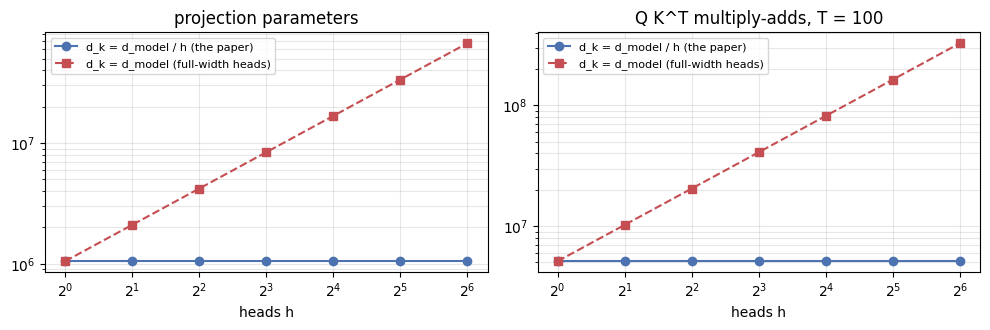

In [18]:
# Parameter and score-FLOP counts as a function of the number of heads, for the two design choices.
def mha_cost(d_model, h, d_k, T):
    '''(parameters, multiply-adds for Q K^T over a length-T sequence) for h heads of width d_k.'''
    params = 3 * d_model * h * d_k + h * d_k * d_model
    score_flops = h * T * T * d_k
    return params, score_flops

hs = [1, 2, 4, 8, 16, 32, 64]
T_cost = 100
paper = [mha_cost(512, h_, 512 // h_, T_cost) for h_ in hs]
full = [mha_cost(512, h_, 512, T_cost) for h_ in hs]
assert len({p for p, _ in paper}) == 1 == len({f for _, f in paper}), 'd_k = d_model/h must give a constant cost'
assert paper[hs.index(8)][0] == 2 ** 20

print(f'  {"heads":>6s} {"d_k = 512/h":>12s} {"params":>12s} {"score FLOPs":>12s} | {"d_k = 512":>10s} {"params":>12s} {"score FLOPs":>12s}')
for h_, (p1, f1), (p2, f2) in zip(hs, paper, full):
    print(f'  {h_:6d} {512 // h_:12d} {p1:12,d} {f1:12,d} | {512:10d} {p2:12,d} {f2:12,d}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for a_, idx, title in [(ax[0], 0, 'projection parameters'), (ax[1], 1, f'Q K^T multiply-adds, T = {T_cost}')]:
    a_.plot(hs, [c[idx] for c in paper], 'o-', color='#4C72B0', label='d_k = d_model / h (the paper)')
    a_.plot(hs, [c[idx] for c in full], 's--', color='#C44E52', label='d_k = d_model (full-width heads)')
    a_.set_xscale('log', base=2); a_.set_yscale('log'); a_.set_xlabel('heads h'); a_.set_title(title)
    a_.grid(alpha=0.3, which='both'); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Widget 3: number of heads and $d_k$

Drag `h` and `d_k` independently. The blue bar is your configuration; the grey reference is the paper's $h = 8$, $d_k = 64$. Along the line $d_k = 512/h$ (for example 16 heads of 32, or 2 heads of 256) the bars do not move; leave $d_k$ fixed and add heads, and the cost grows linearly with $h$.

In [19]:
def heads_demo(h_=8, d_k_=64):
    p, f_ = mha_cost(512, h_, d_k_, T_cost)
    p0, f0 = mha_cost(512, 8, 64, T_cost)
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.2))
    for a_, (v, v0, title) in zip(ax, [(p, p0, 'projection parameters'), (f_, f0, f'score multiply-adds (T = {T_cost})')]):
        bars = a_.bar(['paper: h=8, d_k=64', f'h={h_}, d_k={d_k_}'], [v0, v], color=['#999999', '#4C72B0'])
        for b, val in zip(bars, [v0, v]):
            a_.text(b.get_x() + b.get_width() / 2, val, f'{val:,}', ha='center', va='bottom', fontsize=8)
        a_.set_title(f'{title}: {v / v0:.2f}x the paper', fontsize=9); a_.margins(y=0.25)
    tag = 'on the constant-cost line d_k = 512 / h' if h_ * d_k_ == 512 else f'total head width h x d_k = {h_ * d_k_} (paper: 512)'
    fig.suptitle(tag, y=1.02)
    plt.tight_layout(); plt.show()

interact(heads_demo, h_=SelectionSlider(options=hs, value=8, description='heads h'),
         d_k_=SelectionSlider(options=[8, 16, 32, 64, 128, 256, 512], value=64, description='d_k'));

interactive(children=(SelectionSlider(description='heads h', index=3, options=(1, 2, 4, 8, 16, 32, 64), value=…

## 5. Positional encoding

> "Unlike RNN and CNN encoders, attention encoder outputs do not depend on order of inputs (Why?)"

The slide leaves the question open. The answer is that nothing in $\mathrm{softmax}(QK^{\top}/\sqrt{d_k})V$ refers to a position: permuting the rows of $X$ permutes $Q$, $K$ and $V$ identically, the scores are permuted in both indices, and the output rows come out in the permuted order. Self-attention is **permutation-equivariant**, and the first cell checks it. Since word order carries meaning in translation and language modelling, position has to be injected explicitly. The slides use the paper's sinusoids:

$$PE_{pos,2i} = \sin\!\left(\frac{pos}{10000^{2i/d_{emb}}}\right), \qquad
PE_{pos,2i+1} = \cos\!\left(\frac{pos}{10000^{2i/d_{emb}}}\right)$$

**A contradiction in the slides worth resolving.** One bullet says the final input embeddings are the **concatenation** of the learnable embedding and the positional encoding. The paper adds them: "we add the positional encodings to the input embeddings" (*Vaswani et al., NeurIPS 2017*, section 3.5), and the architecture figures on the encoder slide and the full-architecture slide both draw a $\oplus$ sum. The widths say the same thing: the slide's own formula gives $PE$ exactly $d_{emb} = d_{model}$ columns, so concatenating it to a $d_{model}$-wide embedding would produce a $2 d_{model} = 1024$-wide input, while the encoder slide insists every sublayer outputs $d_{model} = 512$. The second cell checks the shapes.

In [20]:
# First, the permutation-equivariance that makes positional encoding necessary.
set_seed(0)
X_small = torch.randn(1, 5, d_model, device=device)
perm = torch.randperm(5, device=device)
out_a, _ = mha512(X_small)
out_b, _ = mha512(X_small[:, perm])
assert torch.allclose(out_a[:, perm], out_b, atol=1e-4), 'attention should be permutation-equivariant'
print(f'  permutation {perm.tolist()}: permuting the inputs permutes the outputs identically,')
print('  so self-attention alone cannot tell position 0 from position 4')

  permutation [1, 3, 0, 2, 4]: permuting the inputs permutes the outputs identically,
  so self-attention alone cannot tell position 0 from position 4


In [21]:
# The sinusoidal encoding, the property at pos = 0, and the slides' contradiction settled.
def positional_encoding(max_len, d_emb, dtype=torch.float32):
    '''Sinusoidal table (max_len, d_emb): even columns sin, odd columns cos, one frequency per pair.'''
    pos = torch.arange(max_len, dtype=dtype)[:, None]
    i = torch.arange(0, d_emb, 2, dtype=dtype)
    denom = torch.pow(10000, i / d_emb)
    pe = torch.zeros(max_len, d_emb, dtype=dtype)
    pe[:, 0::2] = torch.sin(pos / denom)
    pe[:, 1::2] = torch.cos(pos / denom)
    return pe

PE = positional_encoding(100, d_model)
assert PE.shape == (100, d_model)
assert torch.allclose(PE[0, 0::2], torch.zeros(d_model // 2), atol=1e-6), 'sin(0) should be 0'
assert torch.allclose(PE[0, 1::2], torch.ones(d_model // 2), atol=1e-6), 'cos(0) should be 1'
print(f'  PE {tuple(PE.shape)};  at pos=0 every sine term is 0 and every cosine term is 1')

emb = torch.randn(100, d_model)
added = emb + PE
concatenated = torch.cat([emb, PE], dim=1)
assert added.shape == (100, d_model), 'addition preserves d_model'
assert concatenated.shape == (100, 2 * d_model), 'concatenation doubles it'
print(f'\n  addition      -> {tuple(added.shape)}   d_model preserved')
print(f'  concatenation -> {tuple(concatenated.shape)}   d_model doubled')
print(f'\n  The paper adds them (Vaswani et al., section 3.5). The encoder requires every sublayer to')
print(f'  output {d_model}, and the residual LayerNorm(x + SubLayer(x)) needs both terms the same width;')
print('  concatenation gives 2 x d_model and breaks both, so the slide bullet is wrong: they are ADDED.')

  PE (100, 512);  at pos=0 every sine term is 0 and every cosine term is 1

  addition      -> (100, 512)   d_model preserved
  concatenation -> (100, 1024)   d_model doubled

  The paper adds them (Vaswani et al., section 3.5). The encoder requires every sublayer to
  output 512, and the residual LayerNorm(x + SubLayer(x)) needs both terms the same width;
  concatenation gives 2 x d_model and breaks both, so the slide bullet is wrong: they are ADDED.


### 5.a What the table looks like

Each pair of columns $(2i, 2i+1)$ is a sine and cosine of the same frequency $\omega_i = 10000^{-2i/d}$, so the wavelengths run from $2\pi$ (column pair 0 flips sign every three positions) to $10000 \cdot 2\pi$ (the last pair barely moves over a hundred positions). Read across a row and you have a binary-counter-like code for the position; read down a column and you have a clock at one frequency. The heatmap uses $d = 128$ so the structure is visible.

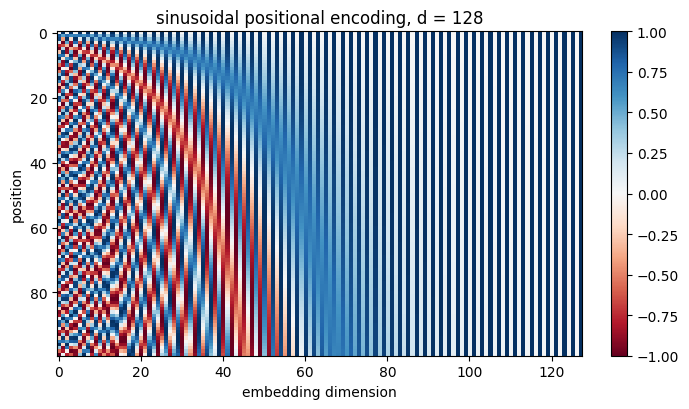

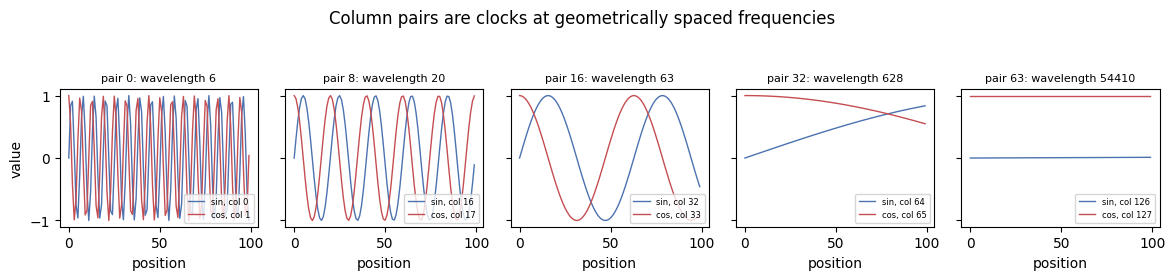

In [22]:
# The positional-encoding table as an image, and a sweep over column pairs.
d_pe = 128
PE128 = positional_encoding(100, d_pe)
omega = 1.0 / torch.pow(10000, torch.arange(0, d_pe, 2).float() / d_pe)      # one frequency per column pair

fig, a_ = plt.subplots(figsize=(7, 4.2))
im = a_.imshow(to_np(PE128), cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
a_.set_xlabel('embedding dimension'); a_.set_ylabel('position'); a_.set_title(f'sinusoidal positional encoding, d = {d_pe}')
plt.colorbar(im, ax=a_, fraction=0.03)
plt.tight_layout(); plt.show()

pairs = [0, 8, 16, 32, 63]
fig, ax = plt.subplots(1, len(pairs), figsize=(12, 2.6), sharey=True)
for a_, i in zip(ax, pairs):
    a_.plot(to_np(PE128[:, 2 * i]), color='#4C72B0', lw=1, label=f'sin, col {2 * i}')
    a_.plot(to_np(PE128[:, 2 * i + 1]), color='#C44E52', lw=1, label=f'cos, col {2 * i + 1}')
    a_.set_title(f'pair {i}: wavelength {2 * math.pi / omega[i]:.0f}', fontsize=8); a_.set_xlabel('position')
    a_.legend(fontsize=6, loc='lower right')
ax[0].set_ylabel('value')
fig.suptitle('Column pairs are clocks at geometrically spaced frequencies', y=1.06)
plt.tight_layout(); plt.show()

### Widget 4: positional-encoding dimension viewer

Drag `pair` from 0 to 63. Low pairs oscillate every few positions and separate neighbours; high pairs change so slowly over 100 positions that they encode only the coarse location. Together they give every position a distinct row, which is what the equivariance of section 5 was missing.

In [23]:
def pe_demo(pair=8):
    w = float(omega[pair])
    fig, a_ = plt.subplots(figsize=(7.5, 3.2))
    a_.plot(to_np(PE128[:, 2 * pair]), color='#4C72B0', label=f'column {2 * pair} = sin(pos * omega)')
    a_.plot(to_np(PE128[:, 2 * pair + 1]), color='#C44E52', label=f'column {2 * pair + 1} = cos(pos * omega)')
    a_.set_xlabel('position'); a_.set_ylabel('value'); a_.set_ylim(-1.1, 1.1); a_.grid(alpha=0.3)
    a_.set_title(f'pair {pair}: omega = 10000^(-{2 * pair}/{d_pe}) = {w:.2e}, wavelength {2 * math.pi / w:,.1f} positions', fontsize=9)
    a_.legend(fontsize=8, loc='lower right')
    plt.tight_layout(); plt.show()

interact(pe_demo, pair=IntSlider(min=0, max=d_pe // 2 - 1, step=1, value=8, description='pair'));

interactive(children=(IntSlider(value=8, description='pair', max=63), Output()), _dom_classes=('widget-interac…

### 5.b Relative offsets are linear functions

The paper chose sinusoids because "for any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$". The reason is the angle-addition identity. For a column pair with frequency $\omega$,

$$\begin{pmatrix} \sin\omega(p+k) \\ \cos\omega(p+k) \end{pmatrix} = \begin{pmatrix} \cos\omega k & \sin\omega k \\ -\sin\omega k & \cos\omega k \end{pmatrix} \begin{pmatrix} \sin\omega p \\ \cos\omega p \end{pmatrix}$$

so $PE_{pos+k} = M_k\, PE_{pos}$ with $M_k$ a block-diagonal rotation that depends on $k$ but not on $pos$. A query projection can therefore learn "attend $k$ positions to the left" as a single matrix. A consequence is that the dot product $PE_{pos} \cdot PE_{pos+k} = \sum_i \cos(\omega_i k)$ depends only on the offset: it is largest at $k = 0$ and falls off with distance. Both statements are checked below in float64.

  k =  1: max |PE[pos+k] - M_k PE[pos]| over 150 positions = 2.1e-14
  k =  5: max |PE[pos+k] - M_k PE[pos]| over 150 positions = 1.6e-14
  k = 17: max |PE[pos+k] - M_k PE[pos]| over 150 positions = 1.6e-14
  k = 60: max |PE[pos+k] - M_k PE[pos]| over 150 positions = 2.1e-14

  PE[p] . PE[p+k] for offsets 0..5: [64.0, 62.09, 57.38, 52.19, 48.59, 47.19]  (independent of p)


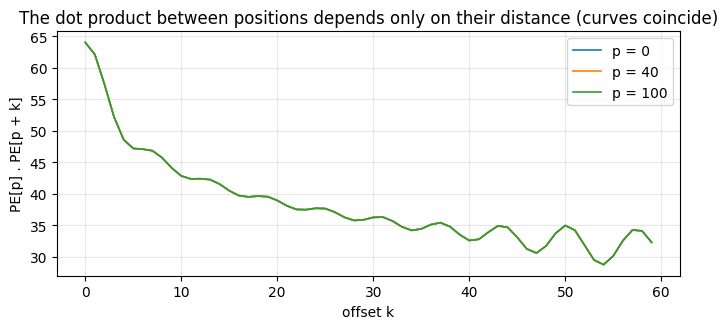

In [24]:
# PE[pos + k] = M_k PE[pos] with M_k independent of pos, and PE[p] . PE[p + k] depends only on k.
PE64 = positional_encoding(260, d_pe, dtype=torch.float64)          # float64 so the identity is tested tightly
omega64 = 1.0 / torch.pow(10000, torch.arange(0, d_pe, 2, dtype=torch.float64) / d_pe)

def offset_matrix(k):
    '''Block-diagonal rotation M_k with PE[pos + k] = M_k @ PE[pos] for every pos.'''
    M = torch.zeros(d_pe, d_pe, dtype=torch.float64)
    for j, w in enumerate(omega64):
        c, s = math.cos(w * k), math.sin(w * k)
        M[2 * j, 2 * j], M[2 * j, 2 * j + 1] = c, s
        M[2 * j + 1, 2 * j], M[2 * j + 1, 2 * j + 1] = -s, c
    return M

for k in (1, 5, 17, 60):
    M_k = offset_matrix(k)
    err = (PE64[k:150 + k] - PE64[:150] @ M_k.T).abs().max()
    assert err < 1e-9, f'offset identity fails for k = {k}'
    print(f'  k = {k:2d}: max |PE[pos+k] - M_k PE[pos]| over 150 positions = {err:.1e}')

dots = PE64 @ PE64.T                                            # (260, 260) matrix of PE[p] . PE[q]
for k in (1, 5, 17):
    diag_k = torch.stack([dots[p, p + k] for p in range(100)])
    assert diag_k.std() < 1e-9, 'the dot product should not depend on the absolute position'
print(f'\n  PE[p] . PE[p+k] for offsets 0..5: {[round(float(dots[0, k]), 2) for k in range(6)]}  (independent of p)')

fig, a_ = plt.subplots(figsize=(7, 3.4))
ks = np.arange(0, 60)
for p in (0, 40, 100):
    a_.plot(ks, to_np(torch.stack([dots[p, p + k] for k in ks])), lw=1.2, label=f'p = {p}')
a_.set_xlabel('offset k'); a_.set_ylabel('PE[p] . PE[p + k]'); a_.grid(alpha=0.3); a_.legend()
a_.set_title('The dot product between positions depends only on their distance (curves coincide)')
plt.tight_layout(); plt.show()

## 6. The encoder and decoder blocks

The **encoder** is a stack of $N = 6$ identical layers. Each has a multi-head self-attention sublayer and a position-wise feedforward network (two linear layers with a ReLU, applied to every position independently), and each sublayer is wrapped in a residual connection followed by layer normalization,

$$\mathrm{LayerNorm}\big(x + \mathrm{SubLayer}(x)\big)$$

so every sublayer outputs $d_{model} = 512$. The **decoder** is also $N = 6$ layers, but each has *two* attention sublayers before its feedforward network. The first is self-attention over the target sequence, **masked** so that a position cannot attend to positions after it: when predicting the current output we must not look into the future of the target. The second attends over the encoder's output: its queries come from the decoder, its keys and values from the encoder, which is exactly the encoder-decoder attention of Lecture 1 written with $Q$, $K$ and $V$.

The cells build one layer of each kind. The encoder layer is checked against `nn.TransformerEncoderLayer` with the weights copied across.

In [25]:
# The position-wise feedforward network and one encoder layer, post-LayerNorm as on the slide.
class FeedForward(nn.Module):
    '''Two linear layers with a ReLU, applied to every position independently.'''
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.lin1, self.lin2 = nn.Linear(d_model, d_ff), nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.lin2(F.relu(self.lin1(x)))

class EncoderLayer(nn.Module):
    '''LayerNorm(x + SelfAttention(x)) followed by LayerNorm(x + FeedForward(x)).'''
    def __init__(self, d_model=512, h=8, d_ff=2048):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, h)
        self.ff = FeedForward(d_model, d_ff)
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        a, A = self.attn(x, mask=mask)
        x = self.norm1(x + a)                     # LayerNorm(x + SubLayer(x))
        return self.norm2(x + self.ff(x)), A

set_seed(0)
layer = EncoderLayer().to(device)
x_in = torch.randn(2, 12, d_model, device=device)
y_out, _ = layer(x_in)
assert y_out.shape == x_in.shape, 'the encoder layer must preserve d_model'
print(f'  encoder layer: {tuple(x_in.shape)} -> {tuple(y_out.shape)}   (the residual needs this)')
print(f'  parameters: {count_params(layer):,}  = attention {count_params(layer.attn):,} + feedforward {count_params(layer.ff):,} + 2 LayerNorms')
print(f'  a stack of N=6 such layers, all at d_model={d_model}')

# Check against nn.TransformerEncoderLayer with the same weights (post-norm, ReLU, no dropout).
ref_layer = nn.TransformerEncoderLayer(d_model, h, dim_feedforward=2048, dropout=0.0, batch_first=True).to(device).eval()
with torch.no_grad():
    ref_layer.self_attn.in_proj_weight.copy_(torch.cat([layer.attn.WQ.weight, layer.attn.WK.weight, layer.attn.WV.weight]))
    ref_layer.self_attn.in_proj_bias.copy_(torch.cat([layer.attn.WQ.bias, layer.attn.WK.bias, layer.attn.WV.bias]))
    ref_layer.self_attn.out_proj.weight.copy_(layer.attn.WO.weight); ref_layer.self_attn.out_proj.bias.copy_(layer.attn.WO.bias)
    ref_layer.linear1.weight.copy_(layer.ff.lin1.weight); ref_layer.linear1.bias.copy_(layer.ff.lin1.bias)
    ref_layer.linear2.weight.copy_(layer.ff.lin2.weight); ref_layer.linear2.bias.copy_(layer.ff.lin2.bias)
    ref_layer.norm1.load_state_dict(layer.norm1.state_dict()); ref_layer.norm2.load_state_dict(layer.norm2.state_dict())
    y_ref = ref_layer(x_in)
assert torch.allclose(y_out, y_ref, atol=1e-4), 'disagrees with nn.TransformerEncoderLayer'
print(f'\n  ours vs nn.TransformerEncoderLayer: max |difference| = {(y_out - y_ref).abs().max():.2e}')

  encoder layer: (2, 12, 512) -> (2, 12, 512)   (the residual needs this)
  parameters: 3,152,384  = attention 1,050,624 + feedforward 2,099,712 + 2 LayerNorms
  a stack of N=6 such layers, all at d_model=512

  ours vs nn.TransformerEncoderLayer: max |difference| = 7.15e-07


In [26]:
# One decoder layer: masked self-attention, attention over the encoder output, feedforward.
class DecoderLayer(nn.Module):
    '''Masked self-attention, then attention with queries from the decoder and keys/values from the
    encoder memory, then the feedforward network; each wrapped in LayerNorm(x + SubLayer(x)).'''
    def __init__(self, d_model=512, h=8, d_ff=2048):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.cross_attn = MultiHeadAttention(d_model, h)
        self.ff = FeedForward(d_model, d_ff)
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(d_model), nn.LayerNorm(d_model), nn.LayerNorm(d_model)

    def forward(self, y, memory, causal_mask=None, memory_mask=None):
        a, A_self = self.self_attn(y, mask=causal_mask)
        y = self.norm1(y + a)
        c, A_cross = self.cross_attn(y, memory, mask=memory_mask)      # queries: decoder, keys/values: encoder
        y = self.norm2(y + c)
        return self.norm3(y + self.ff(y)), A_self, A_cross

def causal_mask(T):
    '''Upper-triangular boolean mask: True above the diagonal = positions after the query are blocked.'''
    return torch.triu(torch.ones(T, T, dtype=torch.bool, device=device), diagonal=1)

set_seed(0)
dec_layer = DecoderLayer().to(device)
memory = torch.randn(2, 12, d_model, device=device)               # encoder output for a 12-token source
y_in = torch.randn(2, 9, d_model, device=device)                  # 9 target positions so far
y_out, A_self, A_cross = dec_layer(y_in, memory, causal_mask(9))
assert y_out.shape == y_in.shape
assert A_self.shape == (2, h, 9, 9) and A_cross.shape == (2, h, 9, 12), 'cross-attention is targets x sources'
print(f'  decoder layer: targets {tuple(y_in.shape)} + memory {tuple(memory.shape)} -> {tuple(y_out.shape)}')
print(f'  self-attention matrix per head {tuple(A_self.shape[2:])}, cross-attention per head {tuple(A_cross.shape[2:])}')
print(f'  parameters: {count_params(dec_layer):,}  (one more attention block than the encoder layer)')

  decoder layer: targets (2, 9, 512) + memory (2, 12, 512) -> (2, 9, 512)
  self-attention matrix per head (9, 9), cross-attention per head (9, 12)
  parameters: 4,204,032  (one more attention block than the encoder layer)


### 6.a The causal mask

The mask sets the scores above the diagonal to $-\infty$ before the softmax, so those weights become exactly zero and each row still sums to 1 over the positions that remain. Two checks make sure it does what the slide says: position 0 attends to itself only, and changing the *last* token leaves every earlier output untouched, so nothing from the future leaks backwards.

In [27]:
# The causal mask: rows still sum to 1, and the future genuinely cannot leak backwards.
T_m = 6
X_m = torch.randn(1, T_m, d_model, device=device)
out_masked, A_m = mha512(X_m, mask=causal_mask(T_m))

assert torch.allclose(A_m.sum(-1), torch.ones(1, h, T_m, device=device), atol=1e-5), 'masked rows must still sum to 1'
assert (A_m[0, :, 0, 1:] == 0).all(), 'position 0 must not see anything after it'

# Change only the LAST token and confirm earlier outputs are untouched.
X_alt = X_m.clone()
X_alt[0, -1] = torch.randn(d_model, device=device)
out_alt, _ = mha512(X_alt, mask=causal_mask(T_m))
assert torch.allclose(out_masked[0, :-1], out_alt[0, :-1], atol=1e-5), 'the future leaked backwards'
out_nomask, _ = mha512(X_m)
out_nomask_alt, _ = mha512(X_alt)
assert not torch.allclose(out_nomask[0, :-1], out_nomask_alt[0, :-1], atol=1e-5), 'without the mask it should leak'

print(f'  attention matrix per head {tuple(A_m.shape[2:])}, still row-stochastic after masking')
print(f'  row 0 attends to {int((A_m[0, 0, 0] > 0).sum())} of {T_m} positions (itself only)')
print(f'  row {T_m - 1} attends to {int((A_m[0, 0, -1] > 0).sum())} of {T_m} positions (all of them)')
print('\n  changing the last token left every earlier output unchanged with the mask,')
print(f'  and changed them by up to {(out_nomask[0, :-1] - out_nomask_alt[0, :-1]).abs().max():.3f} without it')

  attention matrix per head (6, 6), still row-stochastic after masking
  row 0 attends to 1 of 6 positions (itself only)
  row 5 attends to 6 of 6 positions (all of them)

  changing the last token left every earlier output unchanged with the mask,
  and changed them by up to 0.303 without it


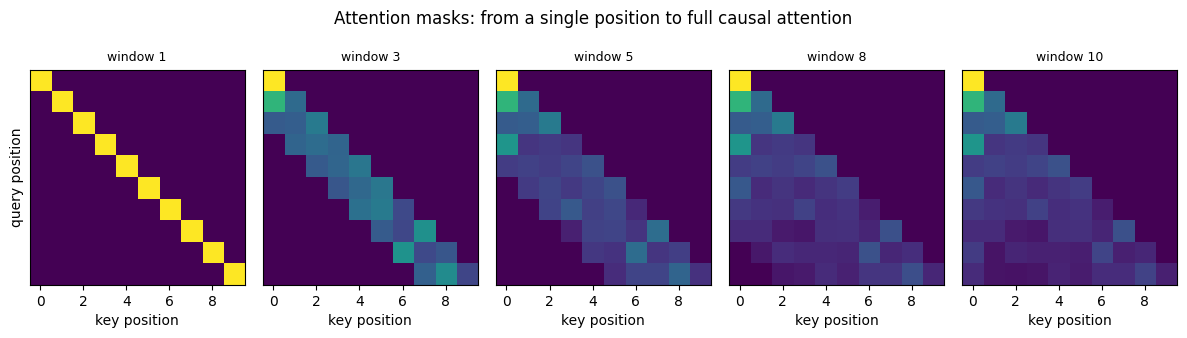

In [28]:
# Static sweep: from a window of one position to full causal attention (head 0 of the untrained mha512).
set_seed(0)
T_v = 10
X_v = torch.randn(1, T_v, d_model, device=device)
fig, ax = plt.subplots(1, 5, figsize=(12, 2.9))
for a_, keep in zip(ax, [1, 3, 5, 8, T_v]):
    rows = torch.arange(T_v, device=device)[:, None]; cols = torch.arange(T_v, device=device)[None, :]
    m = (cols > rows) | (cols < rows - keep + 1)            # block the future and anything older than the window
    _, A_v = mha512(X_v, mask=m)
    a_.imshow(to_np(A_v[0, 0]), cmap='viridis'); a_.set_xlabel('key position')
    a_.set_title(f'window {keep}', fontsize=9); a_.set_yticks([])
ax[0].set_ylabel('query position')
fig.suptitle('Attention masks: from a single position to full causal attention', y=1.04)
plt.tight_layout(); plt.show()

### Widget 5: mask on and off

Drag `T_show` and `head`, and toggle `causal_mask`. With the mask on, everything above the diagonal is exactly zero and the first row is a single bright cell; with it off, every row spreads over all positions. The heads are untrained, so the patterns are random, but the row sums stay at 1 either way.

In [29]:
def show_attn(head=0, T_show=10, causal_mask_on=True):
    set_seed(0)
    Xs = torch.randn(1, T_show, d_model, device=device)
    _, A_s = mha512(Xs, mask=causal_mask(T_show) if causal_mask_on else None)
    fig, a_ = plt.subplots(figsize=(4.6, 4.2))
    im = a_.imshow(to_np(A_s[0, head]), cmap='viridis')
    a_.set_xlabel('key position'); a_.set_ylabel('query position')
    a_.set_title(f'head {head}, T={T_show}, causal={causal_mask_on}\nrow sums {A_s[0, head].sum(-1).mean():.3f}')
    plt.colorbar(im, ax=a_, fraction=0.046)
    plt.tight_layout(); plt.show()

interact(show_attn, head=IntSlider(min=0, max=7, step=1, value=0),
                    T_show=IntSlider(min=4, max=20, step=2, value=10, continuous_update=False),
                    causal_mask_on=Checkbox(value=True, description='causal_mask'));

interactive(children=(IntSlider(value=0, description='head', max=7), IntSlider(value=10, continuous_update=Fal…

### 6.b The full architecture

The last slide of the architecture puts it together: token embeddings plus positional encoding on both sides, $N$ encoder layers, $N$ decoder layers, and a linear layer with a softmax over the vocabulary on top of the decoder. Two details from the paper are kept: the embeddings are multiplied by $\sqrt{d_{model}}$ so that they are not swamped by the positional encoding, and padded source positions are masked out as keys so that a shorter sequence in a batch behaves as if the padding were not there. The class stores every attention matrix of its last forward pass for section 8, and has two switches used in the experiments: `use_causal_mask` and `pe_scale`.

In [30]:
# The complete encoder-decoder transformer, from the blocks above.
class Transformer(nn.Module):
    '''Embedding + positional encoding, N encoder layers, N decoder layers, output projection.'''
    def __init__(self, vocab, d_model=64, h=4, d_ff=128, n_enc=2, n_dec=2, max_len=64, pad_id=None):
        super().__init__()
        self.d_model, self.pad_id = d_model, pad_id
        self.src_emb, self.tgt_emb = nn.Embedding(vocab, d_model), nn.Embedding(vocab, d_model)
        self.register_buffer('pe', positional_encoding(max_len, d_model))
        self.encoder = nn.ModuleList([EncoderLayer(d_model, h, d_ff) for _ in range(n_enc)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, h, d_ff) for _ in range(n_dec)])
        self.out = nn.Linear(d_model, vocab)
        self.use_causal_mask, self.pe_scale = True, 1.0
        self.maps = {}

    def embed(self, emb, tokens):
        return emb(tokens) * math.sqrt(self.d_model) + self.pe_scale * self.pe[:tokens.shape[1]]

    def encode(self, src):
        pad = (src == self.pad_id)[:, None, None, :] if self.pad_id is not None else None   # (B,1,1,T_k)
        x, self.maps['enc'] = self.embed(self.src_emb, src), []
        for layer in self.encoder:
            x, A = layer(x, mask=pad); self.maps['enc'].append(A)
        return x, pad

    def decode(self, tgt_in, state):
        memory, pad = state
        T = tgt_in.shape[1]
        mask = causal_mask(T) if self.use_causal_mask else None
        y, self.maps['dec_self'], self.maps['cross'] = self.embed(self.tgt_emb, tgt_in), [], []
        for layer in self.decoder:
            y, A_s, A_c = layer(y, memory, mask, pad); self.maps['dec_self'].append(A_s); self.maps['cross'].append(A_c)
        return self.out(y)

    def forward(self, src, tgt_in):
        return self.decode(tgt_in, self.encode(src))

set_seed(0)
demo = Transformer(vocab=13, pad_id=12).to(device)
src_demo = torch.randint(0, 10, (2, 6), device=device)
tgt_demo = torch.randint(0, 10, (2, 5), device=device)
logits_demo = demo(src_demo, tgt_demo)
assert logits_demo.shape == (2, 5, 13), 'one distribution over the vocabulary per target position'
print(f'  source {tuple(src_demo.shape)}, target-in {tuple(tgt_demo.shape)} -> logits {tuple(logits_demo.shape)}')
print(f'  stored attention maps: encoder {len(demo.maps["enc"])} layers of {tuple(demo.maps["enc"][0].shape)}, '
      f'cross {tuple(demo.maps["cross"][0].shape)}')
print(f'  this small model: {count_params(demo):,} parameters (d_model 64, 4 heads, 2 + 2 layers)')

# The paper's base model, for the parameter count only (kept on the CPU).
paper_model = Transformer(vocab=13, d_model=512, h=8, d_ff=2048, n_enc=6, n_dec=6)
blocks = sum(count_params(m) for m in list(paper_model.encoder) + list(paper_model.decoder))
print(f'  the paper\'s sizes (512, 8 heads, 2048, 6 + 6 layers): {blocks / 1e6:.1f} M parameters in the blocks;')
print(f'  with a shared 37,000-word embedding ({37000 * 512 / 1e6:.1f} M) that is {(blocks + 37000 * 512) / 1e6:.0f} M, the paper reports 65 M')
del paper_model

  source (2, 6), target-in (2, 5) -> logits (2, 5, 13)
  stored attention maps: encoder 2 layers of (2, 4, 6, 6), cross (2, 4, 5, 6)
  this small model: 169,933 parameters (d_model 64, 4 heads, 2 + 2 layers)


  the paper's sizes (512, 8 heads, 2048, 6 + 6 layers): 44.1 M parameters in the blocks;
  with a shared 37,000-word embedding (18.9 M) that is 63 M, the paper reports 65 M


## 7. Training a transformer: the reverse task

Time to train the thing. The task is small enough for a CPU and hard enough to be informative: **reverse a sequence of digits**. The source is a sequence of 3 to 10 random digits followed by an end-of-sequence marker `EOS`; the target is the same digits in reverse order, followed by `EOS`. Output position $t$ must copy source position $L - 1 - t$, so the model has to combine content (which digit) with position (which one is $L - 1 - t$), and it has to know where the source ends. The recurrent seq2seq model of Lecture 1 has to squeeze all of that into one fixed vector; the transformer can attend straight to the right source position.

Sequences of different lengths share a batch by padding on the right with a `PAD` token. Padded source positions are masked as attention keys, and padded target positions are ignored by the loss.

In [31]:
# The reverse task: mixed-length batches of digits with EOS and PAD, and the shifted decoder input.
DIGITS, BOS, EOS, PAD = 10, 10, 11, 12
VOCAB = 13
TOKEN_NAMES = [str(i) for i in range(10)] + ['BOS', 'EOS', 'PAD']

def make_batch(B, L_min, L_max, gen):
    '''B random digit sequences with lengths in [L_min, L_max], padded on the right.
    src: digits, EOS, PAD...   tgt: reversed digits, EOS, PAD...   tgt_in: BOS, then tgt shifted right.'''
    lens = torch.randint(L_min, L_max + 1, (B,), generator=gen)
    T = int(lens.max()) + 1                                        # room for EOS
    digits = torch.randint(0, DIGITS, (B, T), generator=gen)
    pos = torch.arange(T)[None, :]
    is_tok, is_eos = pos < lens[:, None], pos == lens[:, None]
    fill = lambda a, b, val: torch.where(a, b, torch.full_like(b, val))
    src = fill(is_tok, digits, PAD); src = torch.where(is_eos, torch.full_like(src, EOS), src)
    rev = digits.gather(1, (lens[:, None] - 1 - pos).clamp(min=0))  # rev[b, j] = digits[b, L - 1 - j]
    tgt = fill(is_tok, rev, PAD); tgt = torch.where(is_eos, torch.full_like(tgt, EOS), tgt)
    tgt_in = torch.cat([torch.full((B, 1), BOS), tgt[:, :-1]], dim=1)
    tgt_in = torch.where(pos <= lens[:, None], tgt_in, torch.full_like(tgt_in, PAD))
    return src.to(device), tgt_in.to(device), tgt.to(device), lens

def tokens_to_str(row):
    return ' '.join(TOKEN_NAMES[int(t)] for t in row)

gen_demo = torch.Generator().manual_seed(3)
src_b, tgt_in_b, tgt_b, lens_b = make_batch(4, 3, 7, gen_demo)
print(f'  batch of 4, lengths {lens_b.tolist()}, padded to {src_b.shape[1]} positions')
for b in range(4):
    print(f'    src    {tokens_to_str(src_b[b])}')
    print(f'    tgt_in {tokens_to_str(tgt_in_b[b])}')
    print(f'    tgt    {tokens_to_str(tgt_b[b])}\n')

  batch of 4, lengths [4, 6, 5, 5], padded to 7 positions
    src    0 0 0 5 EOS PAD PAD
    tgt_in BOS 5 0 0 0 PAD PAD
    tgt    5 0 0 0 EOS PAD PAD

    src    1 5 9 6 9 5 EOS
    tgt_in BOS 5 9 6 9 5 1
    tgt    5 9 6 9 5 1 EOS

    src    0 4 6 9 1 EOS PAD
    tgt_in BOS 1 9 6 4 0 PAD
    tgt    1 9 6 4 0 EOS PAD

    src    8 7 4 4 0 EOS PAD
    tgt_in BOS 0 4 4 7 8 PAD
    tgt    0 4 4 7 8 EOS PAD



### 7.a Teacher forcing and the causal mask

At training time the decoder is fed the *true* previous target tokens, shifted right by one with `BOS` in front, and asked to predict the whole target in a single parallel pass: this is **teacher forcing**, and it is what makes transformer training parallel over target positions too. The table above shows the alignment: at position $t$ the decoder reads `tgt_in[t]`, which is `tgt[t-1]`, and must predict `tgt[t]`. But `tgt_in[t+1]` *is* `tgt[t]`, sitting one position to the right in the same input tensor. Without the causal mask the decoder can satisfy the training objective by copying it, so its teacher-forced predictions look fine, and at test time, when only the model's own previous outputs exist, there is nothing to copy. Section 7.d measures exactly that failure. At test time decoding is **autoregressive**: one token at a time, each fed back as the next input.

In [32]:
# Training and greedy decoding, shared by the transformer and the recurrent baseline below.
def train_seq2seq(model, steps, lr, warmup, seed=0, B=128, L_min=3, L_max=10, log_every=200):
    '''Teacher-forced training on the reverse task: Adam, linear warmup, cross-entropy ignoring PAD.'''
    set_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses, t0 = [], time.perf_counter()
    for step in range(steps):
        for g in opt.param_groups:
            g['lr'] = lr * min(1.0, (step + 1) / warmup)
        src, tgt_in, tgt, _ = make_batch(B, L_min, L_max, gen)
        logits = model(src, tgt_in)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB), tgt.reshape(-1), ignore_index=PAD)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        if step % log_every == 0 or step == steps - 1:
            print(f'  step {step:4d}  loss {loss.item():.4f}  lr {opt.param_groups[0]["lr"]:.1e}')
    print(f'  trained {steps} steps in {time.perf_counter() - t0:.1f} s')
    return np.array(losses)

@torch.no_grad()
def greedy_decode(model, src, n_steps):
    '''Autoregressive decoding: start from BOS, append the argmax token n_steps times.'''
    state = model.encode(src)
    ys = torch.full((src.shape[0], 1), BOS, device=device)
    for _ in range(n_steps):
        nxt = model.decode(ys, state)[:, -1].argmax(-1, keepdim=True)
        ys = torch.cat([ys, nxt], dim=1)
    return ys[:, 1:]

@torch.no_grad()
def accuracy_vs_length(model, lengths, n=400, seed=123):
    '''Token accuracy and whole-sequence accuracy of greedy decoding at each length.'''
    gen = torch.Generator().manual_seed(seed)
    tok, seq = [], []
    for L in lengths:
        src, _, tgt, _ = make_batch(n, L, L, gen)
        hit = greedy_decode(model, src, L + 1) == tgt
        tok.append(hit.float().mean().item()); seq.append(hit.all(1).float().mean().item())
    return np.array(tok), np.array(seq)

print('  training and decoding helpers defined')

  training and decoding helpers defined


### 7.b Train the transformer

The model is the `Transformer` of section 6 at a small size: $d_{model} = 64$, 4 heads of $d_k = 16$, $d_{ff} = 128$, two encoder and two decoder layers, no dropout. It trains for 1000 steps of 128 mixed-length sequences with Adam and a 300-step linear warmup (post-LayerNorm transformers are unstable at a full learning rate from step 0). Training lengths are 3 to 10; evaluation goes up to 14, so lengths 11 to 14 are positions the model has never seen.

In [33]:
# Train the transformer on the reverse task.
set_seed(0)
model_tf = Transformer(vocab=VOCAB, d_model=64, h=4, d_ff=128, n_enc=2, n_dec=2, pad_id=PAD).to(device)
print(f'  transformer: {count_params(model_tf):,} parameters')
losses_tf = train_seq2seq(model_tf, steps=1000, lr=3e-3, warmup=300, seed=0)

LENGTHS = list(range(3, 15))
tok_tf, seq_tf = accuracy_vs_length(model_tf, LENGTHS)
print('\n  greedy decoding accuracy (token / whole sequence):')
print('  ' + '  '.join(f'L={L}: {t:.2f}/{s:.2f}' for L, t, s in zip(LENGTHS, tok_tf, seq_tf)))

  transformer: 169,933 parameters


  step    0  loss 2.8155  lr 1.0e-05


  step  200  loss 0.9294  lr 2.0e-03


  step  400  loss 0.3011  lr 3.0e-03


  step  600  loss 0.0820  lr 3.0e-03


  step  800  loss 0.0201  lr 3.0e-03


  step  999  loss 0.0085  lr 3.0e-03
  trained 1000 steps in 23.7 s



  greedy decoding accuracy (token / whole sequence):
  L=3: 1.00/1.00  L=4: 1.00/1.00  L=5: 1.00/1.00  L=6: 1.00/1.00  L=7: 1.00/1.00  L=8: 1.00/0.99  L=9: 0.99/0.96  L=10: 0.98/0.91  L=11: 0.78/0.11  L=12: 0.49/0.00  L=13: 0.21/0.00  L=14: 0.15/0.00


### 7.c The recurrent baseline

The comparison is the encoder-decoder of Lecture 1 without attention: a GRU reads the source and its state at the `EOS` position becomes the initial state of a GRU decoder, which is trained with the same teacher forcing on the same batches. Its hidden size is chosen so that the parameter counts are comparable. Everything else (optimizer, batches, steps, evaluation) is identical.

In [34]:
# GRU seq2seq without attention: the bottleneck model, trained and decoded with the same helpers.
class GRUSeq2Seq(nn.Module):
    '''Encoder GRU -> state at EOS -> decoder GRU -> vocabulary logits. No attention.'''
    def __init__(self, vocab, d_emb=64, hidden=128, pad_id=PAD):
        super().__init__()
        self.pad_id = pad_id
        self.emb = nn.Embedding(vocab, d_emb)
        self.enc = nn.GRU(d_emb, hidden, batch_first=True)
        self.dec = nn.GRU(d_emb, hidden, batch_first=True)
        self.out = nn.Linear(hidden, vocab)

    def encode(self, src):
        out, _ = self.enc(self.emb(src))
        last = (src != self.pad_id).sum(1) - 1                    # index of EOS in each row
        return out[torch.arange(src.shape[0], device=src.device), last][None]   # (1, B, hidden)

    def decode(self, tgt_in, state):
        out, _ = self.dec(self.emb(tgt_in), state)
        return self.out(out)

    def forward(self, src, tgt_in):
        return self.decode(tgt_in, self.encode(src))

set_seed(0)
model_gru = GRUSeq2Seq(VOCAB).to(device)
print(f'  GRU seq2seq: {count_params(model_gru):,} parameters (transformer: {count_params(model_tf):,})')
losses_gru = train_seq2seq(model_gru, steps=1000, lr=2e-3, warmup=100, seed=0)

tok_gru, seq_gru = accuracy_vs_length(model_gru, LENGTHS)
print('\n  greedy decoding accuracy (token / whole sequence):')
print('  ' + '  '.join(f'L={L}: {t:.2f}/{s:.2f}' for L, t, s in zip(LENGTHS, tok_gru, seq_gru)))

# Where the bottleneck bites: accuracy per output position at L = 10 (output 0 is the digit read last).
src10, _, tgt10, _ = make_batch(400, 10, 10, torch.Generator().manual_seed(123))
pos_acc_gru = (greedy_decode(model_gru, src10, 11) == tgt10).float().mean(0)
print('\n  GRU accuracy per output position at L = 10 (output 0 = digit read last, output 9 = digit read first):')
print('  ' + '  '.join(f'{t}: {a:.2f}' for t, a in enumerate(pos_acc_gru[:10].tolist())) + f'   EOS: {pos_acc_gru[10]:.2f}')

  GRU seq2seq: 151,501 parameters (transformer: 169,933)
  step    0  loss 2.5844  lr 2.0e-05


  step  200  loss 0.4369  lr 2.0e-03


  step  400  loss 0.2150  lr 2.0e-03


  step  600  loss 0.1335  lr 2.0e-03


  step  800  loss 0.1966  lr 2.0e-03


  step  999  loss 0.0929  lr 2.0e-03
  trained 1000 steps in 6.2 s



  greedy decoding accuracy (token / whole sequence):
  L=3: 1.00/1.00  L=4: 1.00/1.00  L=5: 1.00/1.00  L=6: 1.00/0.99  L=7: 0.99/0.96  L=8: 0.96/0.86  L=9: 0.91/0.68  L=10: 0.85/0.44  L=11: 0.73/0.16  L=12: 0.62/0.04  L=13: 0.53/0.00  L=14: 0.47/0.00

  GRU accuracy per output position at L = 10 (output 0 = digit read last, output 9 = digit read first):
  0: 0.98  1: 0.95  2: 0.89  3: 0.84  4: 0.85  5: 0.83  6: 0.77  7: 0.76  8: 0.74  9: 0.71   EOS: 1.00


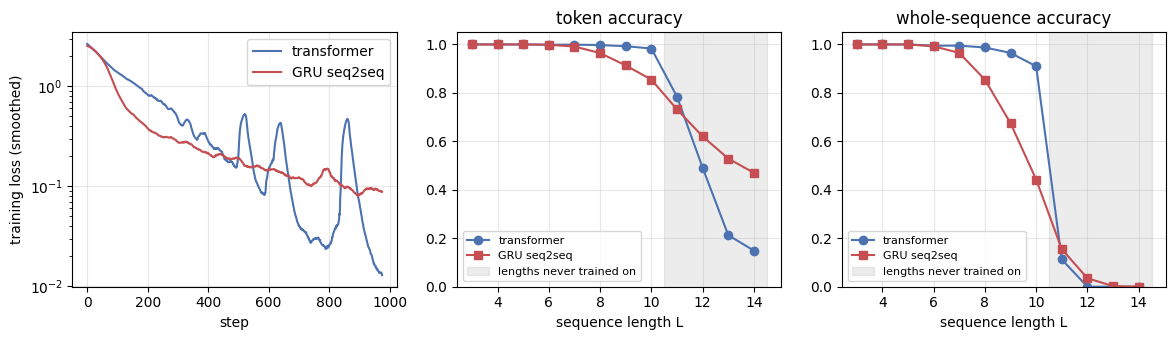

  mean token accuracy on trained lengths 3-10: transformer 0.996, GRU 0.965
  at L = 10: transformer 0.98 token / 0.91 sequence, GRU 0.85 / 0.44
  at L = 12 (never seen): transformer 0.49 token, GRU 0.62


In [35]:
# Loss curves and accuracy versus length for the two models.
smooth = lambda a, k=25: np.convolve(a, np.ones(k) / k, mode='valid')
fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].plot(smooth(losses_tf), color='#4C72B0', label='transformer')
ax[0].plot(smooth(losses_gru), color='#C44E52', label='GRU seq2seq')
ax[0].set_yscale('log'); ax[0].set_xlabel('step'); ax[0].set_ylabel('training loss (smoothed)'); ax[0].legend(); ax[0].grid(alpha=0.3)
for a_, y_tf, y_gru, title in [(ax[1], tok_tf, tok_gru, 'token accuracy'), (ax[2], seq_tf, seq_gru, 'whole-sequence accuracy')]:
    a_.plot(LENGTHS, y_tf, 'o-', color='#4C72B0', label='transformer')
    a_.plot(LENGTHS, y_gru, 's-', color='#C44E52', label='GRU seq2seq')
    a_.axvspan(10.5, 14.5, color='grey', alpha=0.15, label='lengths never trained on')
    a_.set_xlabel('sequence length L'); a_.set_ylim(0, 1.05); a_.set_title(title); a_.grid(alpha=0.3); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()
in_range = slice(0, 8)                                             # lengths 3..10
print(f'  mean token accuracy on trained lengths 3-10: transformer {tok_tf[in_range].mean():.3f}, GRU {tok_gru[in_range].mean():.3f}')
print(f'  at L = 10: transformer {tok_tf[7]:.2f} token / {seq_tf[7]:.2f} sequence, GRU {tok_gru[7]:.2f} / {seq_gru[7]:.2f}')
print(f'  at L = 12 (never seen): transformer {tok_tf[9]:.2f} token, GRU {tok_gru[9]:.2f}')

Two things are visible. Within the trained range the transformer stays near perfect while the GRU's accuracy slides as the sequence grows: this is the bottleneck of Lecture 1 measured directly, since ten digits have to survive a single 128-dimensional vector. The per-position numbers show where the damage is: at $L = 10$ the GRU gets output 0, the digit it read last, right 98% of the time, and accuracy falls almost monotonically along the output to 0.71 at output 9, the digit it read first, which nine later updates of the state have partly overwritten (`EOS`, which needs no memory at all, is always right). Beyond the trained range both models degrade, and the transformer degrades faster. Absolute positions 11 to 14 were never seen by its attention heads, and nothing in the sinusoidal table forces the learned queries to behave sensibly there, whereas the GRU's recurrence at least keeps running the same update. Length extrapolation is a known weakness of absolute positional encodings; exercise 4 asks what happens with a wider training range.

### 7.d What the causal mask is for, measured

The claim in 7.a was that without the mask the decoder can learn to read the next input token instead of predicting it, so that accuracy under teacher forcing says nothing about decoding. The cell trains a second transformer with `use_causal_mask = False` for 800 steps and reports two accuracies for it and for the masked model: **teacher-forced** accuracy, where the decoder is fed the true shifted target as in training, and **free-running** accuracy from `greedy_decode`, where no future token exists to copy.

In [36]:
# Train without the causal mask: teacher-forced accuracy looks fine, free-running decoding does not work.
@torch.no_grad()
def teacher_forced_accuracy(model, L, n=400, seed=5):
    '''Token accuracy when the decoder is fed the true shifted target, exactly as during training.'''
    src, tgt_in, tgt, _ = make_batch(n, L, L, torch.Generator().manual_seed(seed))
    pred = model(src, tgt_in).argmax(-1)
    keep = tgt != PAD
    return (pred[keep] == tgt[keep]).float().mean().item()

set_seed(0)
model_nomask = Transformer(vocab=VOCAB, d_model=64, h=4, d_ff=128, n_enc=2, n_dec=2, pad_id=PAD).to(device)
model_nomask.use_causal_mask = False
losses_nomask = train_seq2seq(model_nomask, steps=800, lr=3e-3, warmup=100, seed=0, log_every=200)

tf_masked, tf_nomask = teacher_forced_accuracy(model_tf, 8), teacher_forced_accuracy(model_nomask, 8)
tok_nomask, _ = accuracy_vs_length(model_nomask, [8])
chance = 1.0 / DIGITS
print(f'\n  {"":>22s} {"with mask":>10s} {"without mask":>13s}')
print(f'  {"train loss, steps 750-800":>22s} {losses_tf[750:800].mean():10.3f} {losses_nomask[750:800].mean():13.3f}')
print(f'  {"teacher-forced acc, L=8":>22s} {tf_masked:10.2f} {tf_nomask:13.2f}')
print(f'  {"free-running acc, L=8":>22s} {tok_tf[5]:10.2f} {tok_nomask[0]:13.2f}   (chance {chance:.2f})')
assert tf_nomask > 0.75, 'without the mask, teacher-forced predictions should still look good'
assert tok_nomask[0] < 0.5, 'and free-running decoding should fail'
print('  the unmasked decoder learned to read tgt[t] from tgt_in[t+1]; at test time that position does not exist')

  step    0  loss 2.8361  lr 3.0e-05


  step  200  loss 0.7795  lr 3.0e-03


  step  400  loss 0.0612  lr 3.0e-03


  step  600  loss 0.1384  lr 3.0e-03


  step  799  loss 0.0079  lr 3.0e-03
  trained 800 steps in 18.8 s

                          with mask  without mask
  train loss, steps 750-800      0.028         0.015
  teacher-forced acc, L=8       1.00          0.90
   free-running acc, L=8       1.00          0.09   (chance 0.10)
  the unmasked decoder learned to read tgt[t] from tgt_in[t+1]; at test time that position does not exist


### 7.e The slide's homework, answered

> "Are transformers faster or slower than LSTMs? What is the reason for your opinion?"

The measurements in this notebook say the answer depends on which pass is meant.

- **Training** (and encoding): faster. Teacher forcing lets the transformer compute every position of the source and the target in one parallel pass, while the LSTM runs $T$ dependent steps. Section 1 measured the forward-plus-backward time on this machine, and the gap grows with the hardware's parallelism.
- **Autoregressive decoding**: each new token still has to be produced after the previous one, so both models are sequential here. The asymptotic argument compares a *stateful* recurrent step with a *cached* transformer step. A recurrent decoder carries its hidden state, so a step is one cell update, $O(1)$ whatever $t$ is. A transformer decoder has no state to carry: even with the key/value cache that real implementations keep, step $t$ attends over all $t$ previous positions, so it costs $O(t)$ and a sequence of $T$ tokens costs $O(T^2)$. The shared `greedy_decode` above is the plain version that re-runs the whole prefix through `model.decode` at every step, which makes the GRU $O(t)$ per step as written and the transformer $O(t^2)$; timing it alone would not test the argument. The cell therefore adds a stateful GRU decoder that feeds only the newest token, checks that it emits exactly the same tokens, and times all three.
- **Path length**: constant for the transformer, $T-1$ for the LSTM, which is why the transformer is also the more accurate of the two at long lengths within its training range (section 7.c).

The cell times greedy decoding of both trained models.

In [37]:
# Autoregressive decoding time versus output length: stateful GRU, prefix-re-running GRU, transformer.
@torch.no_grad()
def greedy_decode_gru(model, src, n_steps):
    '''Stateful greedy decoding for the GRU: carry h and feed only the newest token, one cell update per step.'''
    h = model.encode(src)
    nxt = torch.full((src.shape[0], 1), BOS, device=device)
    out = []
    for _ in range(n_steps):
        o, h = model.dec(model.emb(nxt), h)                          # O(1) per step: no prefix is re-read
        nxt = model.out(o)[:, -1].argmax(-1, keepdim=True)
        out.append(nxt)
    return torch.cat(out, dim=1)

print(f'  {"L":>4s} {"GRU stateful":>13s} {"GRU re-run prefix":>18s} {"transformer":>12s} {"tf / stateful":>14s}')
decode_rows = []
for L in (4, 8, 16, 32):
    src, _, _, _ = make_batch(64, L, L, torch.Generator().manual_seed(0))
    assert torch.equal(greedy_decode_gru(model_gru, src, L + 1), greedy_decode(model_gru, src, L + 1)), 'same tokens either way'
    t_s = time_fn(lambda: greedy_decode_gru(model_gru, src, L + 1), repeats=3)
    t_g = time_fn(lambda: greedy_decode(model_gru, src, L + 1), repeats=3)
    t_t = time_fn(lambda: greedy_decode(model_tf, src, L + 1), repeats=3)
    decode_rows.append((L, t_s, t_g, t_t))
    print(f'  {L:4d} {1e3 * t_s:11.1f}ms {1e3 * t_g:16.1f}ms {1e3 * t_t:10.1f}ms {t_t / t_s:14.1f}')

(L0, s0, g0, tf0), (L1, s1, g1, tf1) = decode_rows[0], decode_rows[-1]
assert tf1 / s1 > tf0 / s0, 'the transformer-to-stateful-GRU ratio should grow with L'
print(f'\n  from L = {L0} to L = {L1} ({L1 // L0}x the steps): stateful GRU {s1 / s0:.0f}x slower (about linear: O(1) per step),')
print(f'  prefix-re-running GRU {g1 / g0:.0f}x and transformer {tf1 / tf0:.0f}x (both re-run the whole prefix every step);')
print(f'  the transformer-to-stateful-GRU ratio grows from {tf0 / s0:.0f}x to {tf1 / s1:.0f}x. A key/value cache would remove')
print('  the re-run, but each transformer step still attends over t stored keys; training is one parallel pass (section 1)')

     L  GRU stateful  GRU re-run prefix  transformer  tf / stateful
     4         0.9ms              1.5ms        6.0ms            6.8


     8         1.5ms              3.9ms       19.3ms           12.8


    16         2.7ms             11.6ms       47.7ms           17.7


    32         5.0ms             38.0ms      123.4ms           24.5

  from L = 4 to L = 32 (8x the steps): stateful GRU 6x slower (about linear: O(1) per step),
  prefix-re-running GRU 25x and transformer 21x (both re-run the whole prefix every step);
  the transformer-to-stateful-GRU ratio grows from 7x to 25x. A key/value cache would remove
  the re-run, but each transformer step still attends over t stored keys; training is one parallel pass (section 1)


## 8. Attention after training

The slides' illustration of multi-head attention shows what trained heads look at. Ours can be inspected directly, because the `Transformer` class stores every attention matrix of its last forward pass. For one source sequence of eight digits, the cells draw the four heads of the last encoder layer (self-attention over the source), the last decoder layer's self-attention over the target prefix (masked), and the same layer's attention over the encoder output. The last one is where reversing happens: output position $t$ should look at source position $L - 1 - t$, an anti-diagonal.

  source     2 1 6 3 7 7 9 8 EOS
  target     8 9 7 7 3 6 1 2 EOS
  predicted  8 9 7 7 3 6 1 2 EOS   (9/9 correct)
  rows (of 8) whose peak lies on the anti-diagonal: head 0: 6, head 1: 5, head 2: 4, head 3: 6


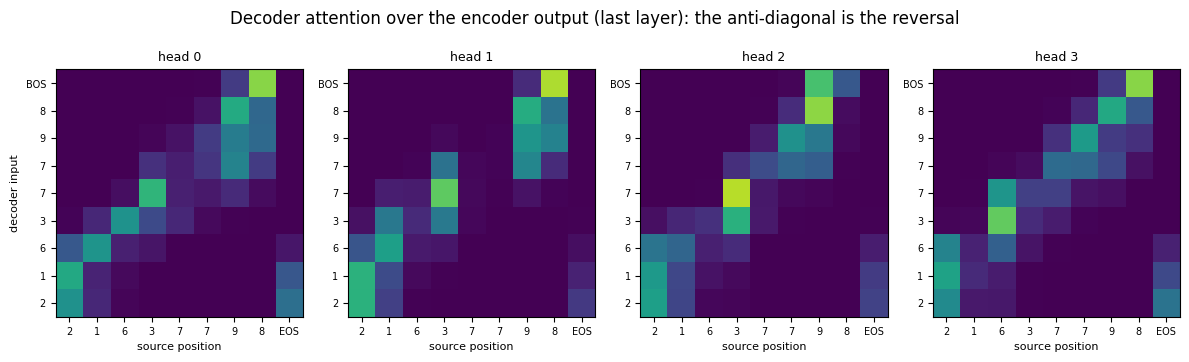

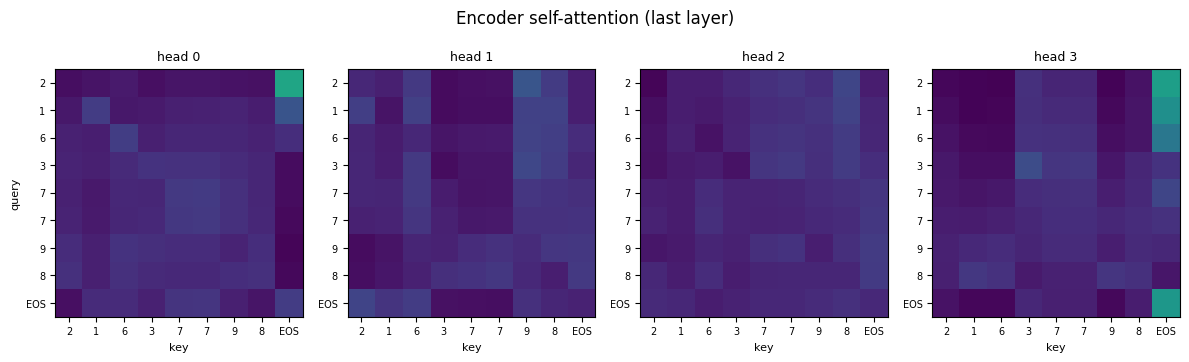

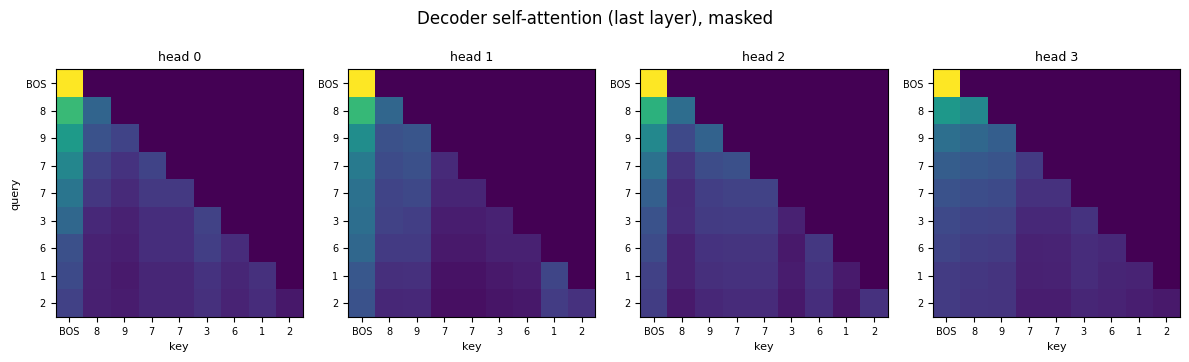

In [38]:
# One example, teacher-forced through the trained model, and its attention maps per head.
gen_ex = torch.Generator().manual_seed(7)
src_ex, tgt_in_ex, tgt_ex, _ = make_batch(1, 8, 8, gen_ex)
with torch.no_grad():
    logits_ex = model_tf(src_ex, tgt_in_ex)
pred_ex = logits_ex.argmax(-1)
src_words = [TOKEN_NAMES[int(t)] for t in src_ex[0]]
tgt_words = [TOKEN_NAMES[int(t)] for t in tgt_ex[0]]
in_words = [TOKEN_NAMES[int(t)] for t in tgt_in_ex[0]]
print(f'  source     {" ".join(src_words)}')
print(f'  target     {" ".join(tgt_words)}')
print(f'  predicted  {" ".join(TOKEN_NAMES[int(t)] for t in pred_ex[0])}   ({int((pred_ex == tgt_ex).sum())}/{tgt_ex.shape[1]} correct)')

A_enc, A_dec, A_cross_ex = model_tf.maps['enc'][-1][0], model_tf.maps['dec_self'][-1][0], model_tf.maps['cross'][-1][0]
n_heads = A_enc.shape[0]

# How well does each cross-attention head track the anti-diagonal? Decoder row t should peak at source L-1-t.
n_dig = src_ex.shape[1] - 1
peaks = A_cross_ex.argmax(-1).detach().cpu()                       # (heads, n_dig + 1): peak source position per row
want = torch.arange(n_dig - 1, -1, -1)                             # rows 0..n_dig-1 should peak at n_dig-1-t
anti_hits = [int((peaks[k, :n_dig] == want).sum()) for k in range(n_heads)]
print('  rows (of ' + str(n_dig) + ') whose peak lies on the anti-diagonal: ' + ', '.join(f'head {k}: {h_}' for k, h_ in enumerate(anti_hits)))

def draw_heads(A_all, row_labels, col_labels, title, xlabel, ylabel):
    fig, ax = plt.subplots(1, n_heads, figsize=(12, 3.3))
    for k, a_ in enumerate(ax):
        a_.imshow(to_np(A_all[k]), cmap='viridis', vmin=0, vmax=1)
        a_.set_xticks(range(len(col_labels))); a_.set_xticklabels(col_labels, fontsize=7)
        a_.set_yticks(range(len(row_labels))); a_.set_yticklabels(row_labels, fontsize=7)
        a_.set_title(f'head {k}', fontsize=9); a_.set_xlabel(xlabel, fontsize=8)
    ax[0].set_ylabel(ylabel, fontsize=8)
    fig.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

draw_heads(A_cross_ex, in_words, src_words, 'Decoder attention over the encoder output (last layer): the anti-diagonal is the reversal',
           'source position', 'decoder input')
draw_heads(A_enc, src_words, src_words, 'Encoder self-attention (last layer)', 'key', 'query')
draw_heads(A_dec, in_words, in_words, 'Decoder self-attention (last layer), masked', 'key', 'query')

The cross-attention heads carry the algorithm, but they share it. Every head shows the anti-diagonal, and no head tracks all of it: the printed counts say that the best two heads put their peak on the anti-diagonal in 6 of the 8 digit rows, the others in 5 and 4. In the rows a head gets right, decoder input `BOS` (which must predict the last source digit) looks at the last digit before `EOS`, and the rows below step leftwards one source position at a time; in the rows it gets wrong the mass is spread over neighbouring positions, and the two equal digits `7 7` in the middle of this source make the content-based part of the lookup ambiguous there. Because the heads split the work, at a given decoding step the peak of the head average, or even of the sharpest single head, does not always sit on the anti-diagonal although the emitted digit is right with probability 1.00: the output is the weighted sum over all four heads and both decoder layers, not any one peak. The replay in 8.a prints both peaks at every step so the reader can see this. The encoder heads are less interpretable, which is typical: they mix in the `EOS` position, since every source token needs to know how far it is from the end to be found later. The decoder self-attention is lower-triangular (each position attends to itself and to the positions before it), as the mask requires.

### 8.a Decoding step by step

Greedy decoding grows the output one token at a time. The cell replays it for the same example and records, at each step, the newest query's cross-attention over the source (all four heads of the last layer) and the softmax over the vocabulary for the token being chosen.

  source: 2 1 6 3 7 7 9 8 EOS
  step 0: input                        BOS -> emits   8 (p = 1.00); sharpest head 1 peaks at source pos 7, head average at 7
  step 1: input                      BOS 8 -> emits   9 (p = 1.00); sharpest head 2 peaks at source pos 6, head average at 6
  step 2: input                    BOS 8 9 -> emits   7 (p = 1.00); sharpest head 3 peaks at source pos 5, head average at 6
  step 3: input                  BOS 8 9 7 -> emits   7 (p = 1.00); sharpest head 1 peaks at source pos 6, head average at 6
  step 4: input                BOS 8 9 7 7 -> emits   3 (p = 1.00); sharpest head 2 peaks at source pos 3, head average at 3
  step 5: input              BOS 8 9 7 7 3 -> emits   6 (p = 1.00); sharpest head 3 peaks at source pos 2, head average at 2
  step 6: input            BOS 8 9 7 7 3 6 -> emits   1 (p = 1.00); sharpest head 1 peaks at source pos 1, head average at 1
  step 7: input          BOS 8 9 7 7 3 6 1 -> emits   2 (p = 1.00); sharpest head 1 peaks at so

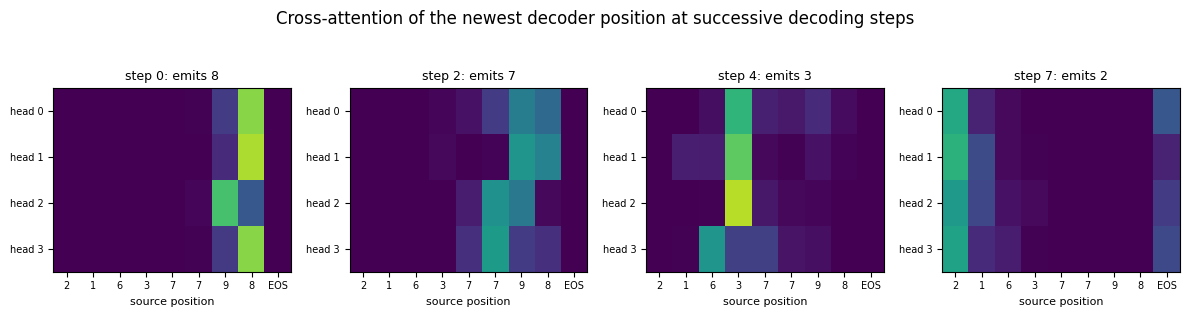

In [39]:
# Replay greedy decoding on the example, recording the newest position's attention and output distribution.
@torch.no_grad()
def decode_trace(model, src, n_steps):
    state = model.encode(src)
    ys = torch.full((1, 1), BOS, device=device)
    trace = []
    for _ in range(n_steps):
        logits = model.decode(ys, state)[:, -1]
        probs = torch.softmax(logits, dim=-1)[0]
        cross = model.maps['cross'][-1][0, :, -1, :]                  # (heads, T_src): newest query row
        nxt = probs.argmax()
        trace.append(dict(prefix=[int(t) for t in ys[0]], probs=to_np(probs), cross=to_np(cross), token=int(nxt)))
        ys = torch.cat([ys, nxt.view(1, 1)], dim=1)
    return trace

trace = decode_trace(model_tf, src_ex, src_ex.shape[1])
print(f'  source: {" ".join(src_words)}')
for t, step in enumerate(trace):
    top = step['probs'].argmax()
    sharp = int(step['cross'].max(1).argmax())                    # the head with the most concentrated row
    print(f'  step {t}: input {tokens_to_str(step["prefix"]):>26s} -> emits {TOKEN_NAMES[step["token"]]:>3s} '
          f'(p = {step["probs"][top]:.2f}); sharpest head {sharp} peaks at source pos {int(step["cross"][sharp].argmax())}, '
          f'head average at {int(step["cross"].mean(0).argmax())}')

steps_shown = [0, 2, 4, 7]
fig, ax = plt.subplots(1, len(steps_shown), figsize=(12, 3.0))
for a_, t in zip(ax, steps_shown):
    a_.imshow(trace[t]['cross'], cmap='viridis', vmin=0, vmax=1, aspect='auto')
    a_.set_xticks(range(len(src_words))); a_.set_xticklabels(src_words, fontsize=7)
    a_.set_yticks(range(n_heads)); a_.set_yticklabels([f'head {k}' for k in range(n_heads)], fontsize=7)
    a_.set_title(f'step {t}: emits {TOKEN_NAMES[trace[t]["token"]]}', fontsize=9); a_.set_xlabel('source position', fontsize=8)
fig.suptitle('Cross-attention of the newest decoder position at successive decoding steps', y=1.04)
plt.tight_layout(); plt.show()

### Widget 6: decoding-step scrubber

Drag `step` from 0 to 8; the last step emits `EOS`. The left panel is the cross-attention of the newest decoder position, one row per head; the right panel is the output distribution at that step, with the correct token marked. Watch the attention peak move from the end of the source towards its beginning as the reversed output is produced, and watch the probability mass stay on a single digit.

In [40]:
def decode_demo(step=0):
    s = trace[step]
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1.3, 1]})
    ax[0].imshow(s['cross'], cmap='viridis', vmin=0, vmax=1, aspect='auto')
    ax[0].set_xticks(range(len(src_words))); ax[0].set_xticklabels(src_words, fontsize=8)
    ax[0].set_yticks(range(n_heads)); ax[0].set_yticklabels([f'head {k}' for k in range(n_heads)], fontsize=8)
    ax[0].set_xlabel('source position'); ax[0].set_title(f'cross-attention of the newest position (input so far: {tokens_to_str(s["prefix"])})', fontsize=8)
    colors = ['#C44E52' if i == int(tgt_ex[0, step]) else '#4C72B0' for i in range(VOCAB)]
    ax[1].bar(range(VOCAB), s['probs'], color=colors)
    ax[1].set_xticks(range(VOCAB)); ax[1].set_xticklabels(TOKEN_NAMES, rotation=60, fontsize=7); ax[1].set_ylim(0, 1)
    ax[1].set_title(f'step {step}: emits {TOKEN_NAMES[s["token"]]}, target {tgt_words[step]} (red)', fontsize=9)
    plt.tight_layout(); plt.show()

interact(decode_demo, step=IntSlider(min=0, max=len(trace) - 1, step=1, value=0, description='step'));

interactive(children=(IntSlider(value=0, description='step', max=8), Output()), _dom_classes=('widget-interact…

## 9. Explore and verify

Three final checks on the trained model, then one last experiment. First, the trained encoder layers are copied into `nn.TransformerEncoderLayer` modules and must produce the same output on real embedded batches, so the verification of section 6 holds for the weights that were actually learned. Second, the attention matrices stored by the model are recomputed with `F.scaled_dot_product_attention` from the layer's own projections. Third, the accuracies of section 7 are checked and printed rather than asserted: training is stochastic and the random stream differs between CPU and GPU, so a run that lands on a worse optimum is reported, not treated as a failure.

In [41]:
# The trained encoder layers agree with nn.TransformerEncoderLayer, and the stored maps with PyTorch's kernel.
src_chk, _, _, _ = make_batch(16, 8, 8, torch.Generator().manual_seed(11))     # equal lengths: no padding mask needed
with torch.no_grad():
    x_chk = model_tf.embed(model_tf.src_emb, src_chk)
    for i, ours_layer in enumerate(model_tf.encoder):
        ref_l = nn.TransformerEncoderLayer(64, 4, dim_feedforward=128, dropout=0.0, batch_first=True).to(device).eval()
        ref_l.self_attn.in_proj_weight.copy_(torch.cat([ours_layer.attn.WQ.weight, ours_layer.attn.WK.weight, ours_layer.attn.WV.weight]))
        ref_l.self_attn.in_proj_bias.copy_(torch.cat([ours_layer.attn.WQ.bias, ours_layer.attn.WK.bias, ours_layer.attn.WV.bias]))
        ref_l.self_attn.out_proj.weight.copy_(ours_layer.attn.WO.weight); ref_l.self_attn.out_proj.bias.copy_(ours_layer.attn.WO.bias)
        ref_l.linear1.load_state_dict(ours_layer.ff.lin1.state_dict()); ref_l.linear2.load_state_dict(ours_layer.ff.lin2.state_dict())
        ref_l.norm1.load_state_dict(ours_layer.norm1.state_dict()); ref_l.norm2.load_state_dict(ours_layer.norm2.state_dict())
        y_ours, A_ours = ours_layer(x_chk)
        y_ref = ref_l(x_chk)
        assert torch.allclose(y_ours, y_ref, atol=1e-4), f'trained encoder layer {i} disagrees with PyTorch'
        # the stored attention, recomputed with PyTorch's kernel from the same projections
        q, k, v = (ours_layer.attn.split_heads(W(x_chk)) for W in (ours_layer.attn.WQ, ours_layer.attn.WK, ours_layer.attn.WV))
        z_ref = F.scaled_dot_product_attention(q, k, v)
        assert torch.allclose(A_ours @ v, z_ref, atol=1e-5), 'stored attention disagrees with SDPA'
        print(f'  trained encoder layer {i}: max |diff| vs nn.TransformerEncoderLayer {(y_ours - y_ref).abs().max():.1e}, '
              f'vs F.scaled_dot_product_attention {(A_ours @ v - z_ref).abs().max():.1e}')
        x_chk = y_ours

# The two training claims are checked softly: training is stochastic, and the random stream differs
# between CPU and GPU, so a run on Colab can land on a worse optimum than the reference run here.
holds = bool(tok_tf[in_range].mean() > 0.9 and tok_tf[7] > tok_gru[7])
print(f'\n  accuracy checks {"hold" if holds else "DID NOT HOLD on this run"}: transformer {tok_tf[in_range].mean():.3f} '
      f'mean token accuracy on lengths 3-10, {tok_tf[7]:.2f} vs GRU {tok_gru[7]:.2f} at L = 10')
if not holds:
    print('  training is stochastic; re-run the two training cells (or lower the peak learning rate) and check again')

  trained encoder layer 0: max |diff| vs nn.TransformerEncoderLayer 7.2e-07, vs F.scaled_dot_product_attention 9.2e-06
  trained encoder layer 1: max |diff| vs nn.TransformerEncoderLayer 9.5e-07, vs F.scaled_dot_product_attention 3.6e-07

  accuracy checks hold: transformer 0.996 mean token accuracy on lengths 3-10, 0.98 vs GRU 0.85 at L = 10


### 9.a Scaling the positional encoding at test time

Section 5 argued that without positional information the encoder output is a set, and the reverse task cannot be solved from a set. The trained model has a `pe_scale` switch that multiplies the positional encoding on both sides at inference, with no retraining. A scale of 0 removes position entirely; 1 is the trained model; larger values push the positional part beyond anything the heads saw during training. The sweep reports token accuracy at $L = 8$ over 300 sequences for each scale, and draws the head-averaged cross-attention of the last layer for the example of section 8.

  token accuracy at L = 8 versus test-time PE scale:
  0: 0.27  0.25: 0.52  0.5: 0.73  0.75: 0.96  1: 1.00  1.25: 0.98  1.5: 0.86  2: 0.65  3: 0.49


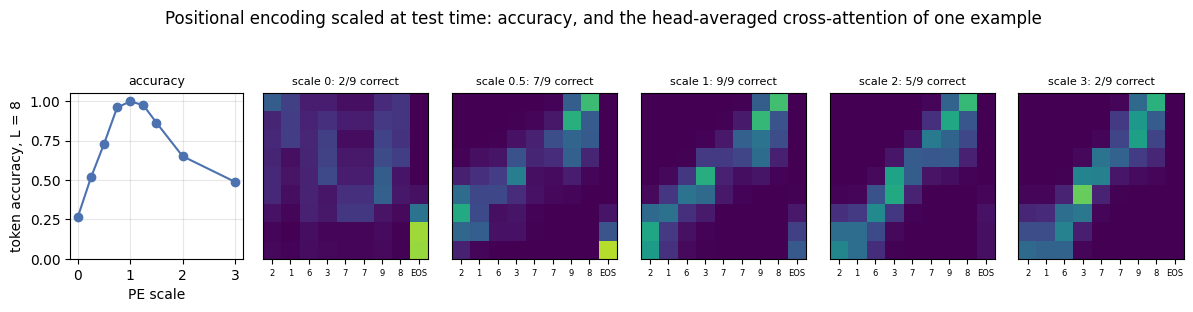

In [42]:
# Test-time sweep over the positional-encoding scale, no retraining.
pe_scales = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
gen_pe = torch.Generator().manual_seed(21)
src_pe, _, tgt_pe, _ = make_batch(300, 8, 8, gen_pe)
examples = [make_batch(1, 8, 8, torch.Generator().manual_seed(s)) for s in (7, 8, 9, 10)]
pe_sweep = {}
with torch.no_grad():
    for s in pe_scales:
        model_tf.pe_scale = s
        acc = (greedy_decode(model_tf, src_pe, 9) == tgt_pe).float().mean().item()
        per_example = []
        for src_e, _, tgt_e, _ in examples:
            pred_e = greedy_decode(model_tf, src_e, 9)
            per_example.append(dict(src=[TOKEN_NAMES[int(t)] for t in src_e[0]], tgt=[TOKEN_NAMES[int(t)] for t in tgt_e[0]],
                                    pred=[TOKEN_NAMES[int(t)] for t in pred_e[0]],
                                    cross=to_np(model_tf.maps['cross'][-1][0].mean(0)), correct=int((pred_e == tgt_e).sum())))
        pe_sweep[s] = dict(acc=acc, examples=per_example)
model_tf.pe_scale = 1.0                                              # restore the trained model
print('  token accuracy at L = 8 versus test-time PE scale:')
print('  ' + '  '.join(f'{s:g}: {pe_sweep[s]["acc"]:.2f}' for s in pe_scales))
assert pe_sweep[0.0]['acc'] < 0.5 < pe_sweep[1.0]['acc'], 'removing position must break the reversal'

shown = [0.0, 0.5, 1.0, 2.0, 3.0]
fig, ax = plt.subplots(1, len(shown) + 1, figsize=(12, 2.9))
ax[0].plot(pe_scales, [pe_sweep[s]['acc'] for s in pe_scales], 'o-', color='#4C72B0')
ax[0].set_xlabel('PE scale'); ax[0].set_ylabel('token accuracy, L = 8'); ax[0].set_ylim(0, 1.05); ax[0].grid(alpha=0.3)
ax[0].set_title('accuracy', fontsize=9)
ex0 = 0
for a_, s in zip(ax[1:], shown):
    e = pe_sweep[s]['examples'][ex0]
    a_.imshow(e['cross'], cmap='viridis', vmin=0, vmax=1)
    a_.set_xticks(range(9)); a_.set_xticklabels(e['src'], fontsize=6); a_.set_yticks([])
    a_.set_title(f'scale {s:g}: {e["correct"]}/9 correct', fontsize=8)
fig.suptitle('Positional encoding scaled at test time: accuracy, and the head-averaged cross-attention of one example', y=1.06)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

### Widget 7: positional-encoding scale and example

Drag `scale` and pick an `example`. At scale 0 the decoder still emits digits from the source, but in an order it cannot know, and the attention map loses its anti-diagonal; at the trained scale the reversal is exact; past about 1.5 the heads see positional vectors they were never trained on and the map falls apart again. Everything shown is precomputed above, so the slider only indexes.

In [43]:
def pe_scale_demo(scale=1.0, example=0):
    e = pe_sweep[scale]['examples'][example]
    fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4), gridspec_kw={'width_ratios': [1, 1.1]})
    ax[0].imshow(e['cross'], cmap='viridis', vmin=0, vmax=1)
    ax[0].set_xticks(range(9)); ax[0].set_xticklabels(e['src'], fontsize=8)
    ax[0].set_yticks(range(9)); ax[0].set_yticklabels(e['tgt'], fontsize=8)
    ax[0].set_xlabel('source position'); ax[0].set_ylabel('target token'); ax[0].set_title('head-averaged cross-attention', fontsize=9)
    ax[1].axis('off')
    ax[1].text(0.0, 0.8, f'source:     {" ".join(e["src"])}', fontsize=10, family='monospace')
    ax[1].text(0.0, 0.6, f'target:     {" ".join(e["tgt"])}', fontsize=10, family='monospace')
    ax[1].text(0.0, 0.4, f'decoded:    {" ".join(e["pred"])}', fontsize=10, family='monospace',
               color='#2a7' if e['correct'] == 9 else '#C44E52')
    ax[1].text(0.0, 0.15, f'{e["correct"]}/9 tokens correct on this example\n'
               f'token accuracy over 300 sequences: {pe_sweep[scale]["acc"]:.2f}', fontsize=9)
    fig.suptitle(f'PE scale {scale:g} at test time (trained at 1.0)', y=1.02)
    plt.tight_layout(); plt.show()

interact(pe_scale_demo, scale=SelectionSlider(options=pe_scales, value=1.0, description='scale'),
         example=IntSlider(min=0, max=len(examples) - 1, step=1, value=0, description='example'));

interactive(children=(SelectionSlider(description='scale', index=4, options=(0.0, 0.25, 0.5, 0.75, 1.0, 1.25, …

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Motivation** | Sequential computation blocks parallelism and the RNN path length grows as $T-1$; attention makes both constant, and section 1 measured the wall-time gap on this machine |
| **Q, K, V** | $Q = XW^Q$, $K = XW^K$, $V = XW^V$; with $x \in \mathbb{R}^{512}$ and $q,k,v \in \mathbb{R}^{64}$ the projections are $512 \times 64$, and $64 = d_{model}/h$ |
| **Scaled dot-product** | $Z = \mathrm{softmax}(QK^\top/\sqrt{d_k})V$; with $d_k = 64$ the divisor is 8, reproducing the slides' 0.88 / 0.12 |
| **Why scale** | Dot-product spread grows like $\sqrt{d_k}$ (measured to within 10%); over 500 rows of unscaled logits the mean softmax maximum rises from 0.68 at $d_k = 8$ to 0.98 at $d_k = 2048$ and the median gradient norm falls from $2.5 \times 10^{-1}$ to $10^{-10}$; the division is a fixed temperature |
| **Multi-head** | $h = 8$ heads at $d_k = d_{model}/h$, concatenated and projected by $W^O$; shape-preserving; $4d_{model}^2 = 2^{20}$ parameters, a cost independent of $h$ |
| **Positional encoding** | Self-attention is permutation-equivariant, so position is **added** (not concatenated); $PE_{pos+k} = M_k PE_{pos}$ with $M_k$ a rotation, so offsets are linear |
| **Encoder / decoder** | $N=6$ layers of $\mathrm{LayerNorm}(x + \mathrm{SubLayer}(x))$; the decoder adds masked self-attention and attention over the encoder; our layer matches `nn.TransformerEncoderLayer` |
| **Causal mask, teacher forcing** | Training is one parallel pass over the shifted target; without the mask teacher-forced accuracy still looks good while free-running decoding fails |
| **On the reverse task** | The transformer stays near perfect across trained lengths while the GRU bottleneck degrades with length; neither extrapolates well beyond the trained lengths |
| **Homework** | Faster to train (parallel over $T$); sequential when decoding, where a stateful GRU step is $O(1)$ and a transformer step attends over the $t$-token prefix: in 7.e the transformer-to-stateful-GRU decode time ratio grows roughly fourfold, from about 7x at $L = 4$ to about 25x at $L = 32$ |

**RNN seq2seq versus transformer at a glance (as measured here)**

| | GRU seq2seq (no attention) | Transformer |
|---|---|---|
| Path between source position $i$ and output $t$ | through every intermediate state | one attention step |
| Training pass | $T$ dependent steps | parallel over all positions (teacher forcing + causal mask) |
| Position information | implicit in the recurrence | explicit sinusoidal encoding, added to the embedding |
| Accuracy on trained lengths 3 to 10 | falls with length (see 7.c) | near perfect |
| Lengths never trained on | degrades gradually | degrades sharply |
| Decoding cost per step | $O(1)$ with the state carried (measured in 7.e); the shared `greedy_decode` re-runs the prefix and is $O(t)$ as written | $O(t)$ with a key/value cache, $O(t^2)$ without one (what 7.e times) |

## Exercises

1. **The homework from the slides.** *Are transformers faster or slower than LSTMs?* Write the answer in two parts, training and autoregressive inference, using the numbers from sections 1 and 7.e. Then explain why a key/value cache turns the transformer's per-step decoding cost from recomputing the whole prefix into a single attention over $t$ stored keys, and why that is still not $O(1)$.

2. **The unanswered question.** The slides ask why attention encoder outputs do not depend on input order, and never answer. Prove permutation equivariance from the formula $\mathrm{softmax}(QK^\top/\sqrt{d_k})V$, then explain precisely which step of the proof fails once the positional encoding is added.

3. **Break the heads.** Retrain `model_tf` with `h=1` and with `h=8` (keep $d_{model} = 64$, so $d_k$ becomes 64 and 8) and report the accuracy-versus-length curve of each. Does a single 64-wide head reverse as well as the four 16-wide heads of `model_tf`, and do eight 8-wide heads add anything? *(In our runs a single head still learned the task but was the weakest of the three: at $L = 10$ its token / whole-sequence accuracy ranged over 0.90 to 0.96 / 0.56 to 0.80 across three seeds and thread settings, against 0.97 / 0.84 for the four 16-wide heads and 0.97 / 0.86 for eight 8-wide heads; on lengths 3 to 7 all three were at or above 0.98 token accuracy. The single-head run varied the most from seed to seed, so report the seed with the numbers.)*

4. **Length extrapolation.** Train with `L_max=14` instead of 10 and evaluate up to 20. Report which lengths the transformer and the GRU now handle, and relate the transformer's behaviour to the offset property of section 5.b: which part of the reverse computation depends on absolute position rather than relative offset?

5. **Temperature at inference.** Replace the argmax in `greedy_decode` with sampling from $\mathrm{softmax}(\text{logits}/\tau)$ and measure token accuracy at $L = 8$ for $\tau \in \{0.5, 1, 2\}$. Connect the result to Widget 2: at which $\tau$ does the sampled output stop being the reversal?

6. **Pixels as tokens.** The next lecture's recall slide notes that treating every pixel of a $3 \times 224 \times 224$ image as a token would need a $(3 \cdot 224 \cdot 224)^2 \approx 2.3 \times 10^{10}$-entry attention matrix. Using `mha_cost` from section 4, compute the score multiply-adds for that sequence length, then for $16 \times 16$ patches (196 tokens), and state the ratio. That ratio is the reason Vision Transformers use patches.